# work_mem sweep — sort / hash spill, on tpch

This notebook is a sibling of `sharedBuffers.ipynb`. It analyses the
**`logs/work_mem/`** sweep on the server: the same tpch workload (pg 18.4) run
at several **`work_mem`** budgets (`wm_4MB`, `wm_16MB`, `wm_32MB`, `wm_64MB`,
`wm_128MB`), each on the **base** schema and the **indexed** schema (`_idx`).

`work_mem` is the per-node budget for sorts and hashes; too little forces spills
to temp files. Its effect is on **temp I/O**, which `shared_buffers` cannot touch.
A cohort here is `(work_mem | index_status)`.

## 1. Fetch the work_mem logs → local `wm_cache/`

Walks `logs/work_mem/wm_*/`, downloads every `query_timing_*` /
`query_samples_*` pair (base and `_idx`), and mirrors them into a **new** local
cache folder `wm_cache/`. On a failed fetch it falls back to that cache.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import paramiko

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_DIR = "/home/user01/GreenSQL/logs/work_mem"
CACHE_DIR = Path("wm_cache")        # dedicated cache for this sweep
RETRIES = 5

PARAM_NAME = "work_mem"
X_KIND = "mem"                  # "mem" -> log2 x-axis; "count" -> linear

# file suffix -> index status
VARIANTS = {"tpch": "base", "tpch_idx": "idx"}

def p_to_val(name):
    m = re.match(r"wm_(\d+)(MB|GB)$", str(name))
    if not m:
        return None
    v = int(m.group(1))
    return v * 1024 if m.group(2) == "GB" else v


def p_label(v):
    v = int(v)
    return f"{v // 1024} GB" if v >= 1024 and v % 1024 == 0 else f"{v} MB"

def fetch_over_ssh():
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    for d in sftp.listdir(REMOTE_DIR):
                        if p_to_val(d) is None:
                            continue
                        dd = f"{REMOTE_DIR}/{d}"
                        try:
                            here = set(sftp.listdir(dd))
                        except IOError:
                            continue
                        for suf in VARIANTS:
                            for kind in ("timing", "samples"):
                                fn = f"query_{kind}_{suf}.csv"
                                if fn in here:
                                    blobs[f"{d}/{fn}"] = sftp.open(f"{dd}/{fn}").read()
                    if not blobs:
                        raise RuntimeError(f"no CSVs under {REMOTE_DIR}")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        for rel, b in blobs.items():
            p = CACHE_DIR / rel
            p.parent.mkdir(parents=True, exist_ok=True)
            p.write_bytes(b)
        print(f"Fetched {PARAM_NAME} logs from {SSH_HOST}; cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.relative_to(CACHE_DIR).as_posix(): p.read_bytes()
                 for p in CACHE_DIR.rglob("*.csv")}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime
                                   for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()
vals = sorted({p_to_val(rel.split('/')[0]) for rel in BLOBS})
print(f"source: {SOURCE};  {len(BLOBS)} files;  "
      f"{PARAM_NAME} values: {[p_label(v) for v in vals]}")

Fetched work_mem logs from 192.168.1.42; cache 'wm_cache/' updated.
source: server;  20 files;  work_mem values: ['4 MB', '16 MB', '32 MB', '64 MB', '128 MB']


## 2. Build per-query data, keyed by `(work_mem, index)`

Each `(work_mem, index)` directory is one **cohort**. Timing is reduced
per-execution like `sharedBuffers`; the samples file adds the
**temp read/written** counters (spill volume) that a `work_mem` study lives on.

In [2]:
def query_group(q):
    return re.sub(r"^queries/", "", str(q)).rsplit("/", 1)[0]


parts_t, parts_s = [], []
for rel, b in BLOBS.items():
    dname, fn = rel.split("/", 1)
    val = p_to_val(dname)
    idx = "idx" if "_idx" in fn else "base"
    df = pd.read_csv(io.BytesIO(b))
    df["pval"] = val
    df["plabel"] = p_label(val)
    df["index_status"] = idx
    df["cohort"] = df["plabel"] + " | " + idx
    (parts_t if "timing" in fn else parts_s).append(df)

timing = pd.concat(parts_t, ignore_index=True)
samples = pd.concat(parts_s, ignore_index=True)
KEY = ["cohort", "query"]

# ---- timing -> per-execution (mean of measured batches, like testPlot) ----
mt = timing[timing["phase"] == "measured"].copy()
for c in ["batchnum", "elapsed_sec", "avg_copy_elapsed_sec", "server_sum_ms",
          "client_overhead_sec", "rapl_pkg_j", "rapl_core_j", "failed"]:
    mt[c] = pd.to_numeric(mt[c], errors="coerce")
mt = mt[mt["failed"].fillna(0) == 0]
bn = mt["batchnum"].replace(0, np.nan)
mt["copy_time"] = mt["avg_copy_elapsed_sec"]
mt["copy_pkg"] = mt["rapl_pkg_j"] / bn
mt["copy_core"] = mt["rapl_core_j"] / bn
mt["copy_overhead"] = mt["client_overhead_sec"] / bn
mt["copy_server"] = (mt["server_sum_ms"] / 1000.0) / bn
for c in ["copy_pkg", "copy_core"]:            # RAPL overflow -> N/A
    mt[c] = mt[c].mask(mt[c] < 0)

tim = mt.groupby(KEY, as_index=False).agg(
    n_batches=("batch_index", "size"),
    avg_time_s=("copy_time", "mean"), time_std=("copy_time", "std"),
    time_min=("copy_time", "min"), time_max=("copy_time", "max"),
    avg_pkg_j=("copy_pkg", "mean"), pkg_j_std=("copy_pkg", "std"),
    avg_core_j=("copy_core", "mean"), core_j_std=("copy_core", "std"),
    server_s=("copy_server", "mean"), overhead_s=("copy_overhead", "mean"),
    pval=("pval", "first"), plabel=("plabel", "first"),
    index_status=("index_status", "first"),
)
tim["time_mean"] = tim["avg_time_s"]
tim["sql_file"] = tim["query"].astype(str).str.split("/").str[-1]
tim["group"] = tim["query"].map(query_group)
tim["qid"] = tim["query"].astype(str).str.replace(
    r"^queries/tpch/tpch-queries/", "", regex=True)

# ---- samples -> server split + buffer / spill / parallelism counters ----
meas = samples[samples["phase"] == "measured"].copy()
for c in ["server_planning_ms", "server_execution_ms", "shared_hit_blks",
          "shared_read_blks", "temp_read_blks", "temp_written_blks",
          "rows_processed", "bytes_processed", "workers_launched",
          "plan_nodes", "scan_nodes", "rows_removed_filter"]:
    if c in meas.columns:
        meas[c] = pd.to_numeric(meas[c], errors="coerce")
agg = dict(
    plan_ms=("server_planning_ms", "mean"), exec_ms=("server_execution_ms", "mean"),
    shared_hit=("shared_hit_blks", "mean"), shared_read=("shared_read_blks", "mean"),
    temp_read=("temp_read_blks", "mean"), temp_written=("temp_written_blks", "mean"),
    rows_processed=("rows_processed", "mean"),
    bytes_processed=("bytes_processed", "mean"),
)
for name, col in (("workers", "workers_launched"), ("plan_nodes", "plan_nodes"),
                  ("scan_nodes", "scan_nodes"), ("rows_removed", "rows_removed_filter")):
    if col in meas.columns:
        agg[name] = (col, "mean")
smp = meas.groupby(KEY).agg(**agg)
smp["plan_ratio"] = smp["plan_ms"] / (smp["plan_ms"] + smp["exec_ms"]).replace(0, np.nan)
blks = (smp["shared_hit"] + smp["shared_read"]).replace(0, np.nan)
smp["cache_hit_pct"] = 100 * smp["shared_hit"] / blks
smp["read_mb"] = smp["shared_read"] * 8 / 1024.0        # 8 KB blocks -> MB
smp["temp_blks"] = smp["temp_read"] + smp["temp_written"]
smp["temp_mb"] = smp["temp_blks"] * 8 / 1024.0

data = tim.merge(smp.reset_index(), on=KEY, how="left")
r = data["plan_ratio"].fillna(0.0)
data["plan_s"] = data["server_s"] * r
data["exec_s"] = data["server_s"] * (1.0 - r)
data["cv_pct"] = 100 * data["time_std"] / data["avg_time_s"]
data["power_w"] = data["avg_pkg_j"] / data["avg_time_s"]
data["label"] = data["sql_file"]

PVALS = sorted(data["pval"].dropna().unique())
IDX_ALL = [s for s in ["base", "idx"] if s in set(data["index_status"])]
colours = {"base": "#4c72b0", "idx": "#dd8452"}


def set_xaxis(ax):
    if X_KIND == "mem":
        ax.set_xscale("log", base=2)
    ax.set_xticks(PVALS)
    ax.set_xticklabels([p_label(v) for v in PVALS])
    ax.set_xlabel(PARAM_NAME)


print(f"{len(data)} (cohort, query) rows; {data['qid'].nunique()} queries; "
      f"{data['group'].nunique()} query folders")
print(f"{PARAM_NAME}: {[p_label(v) for v in PVALS]}; index: {IDX_ALL}")
print(data.groupby(['plabel', 'index_status']).agg(
    queries=('qid', 'nunique'),
    total_runtime_s=('avg_time_s', 'sum'),
    total_energy_j=('avg_pkg_j', 'sum')).round(2).to_string())

530 (cohort, query) rows; 53 queries; 21 query folders
work_mem: ['4 MB', '16 MB', '32 MB', '64 MB', '128 MB']; index: ['base', 'idx']
                     queries  total_runtime_s  total_energy_j
plabel index_status                                          
128 MB base               53           148.34         1710.13
       idx                53            37.54          646.06
16 MB  base               53           140.78         1560.73
       idx                53            30.21          542.25
32 MB  base               53           142.59         1593.28
       idx                53            32.15          533.72
4 MB   base               53           137.50         1593.55
       idx                53            29.17          578.58
64 MB  base               53           149.91         1752.70
       idx                53            39.22          683.49


## 3. Main per-query plots, one figure per tpch query folder

Same layout as `sharedBuffers` §3. Each bar is `variant [work_mem | index]`;
**indexed** bars are hatched (`xx`); bars are ordered by `work_mem`. Figures are
split into runtime bins.

21 query folder(s) -> 24 figures


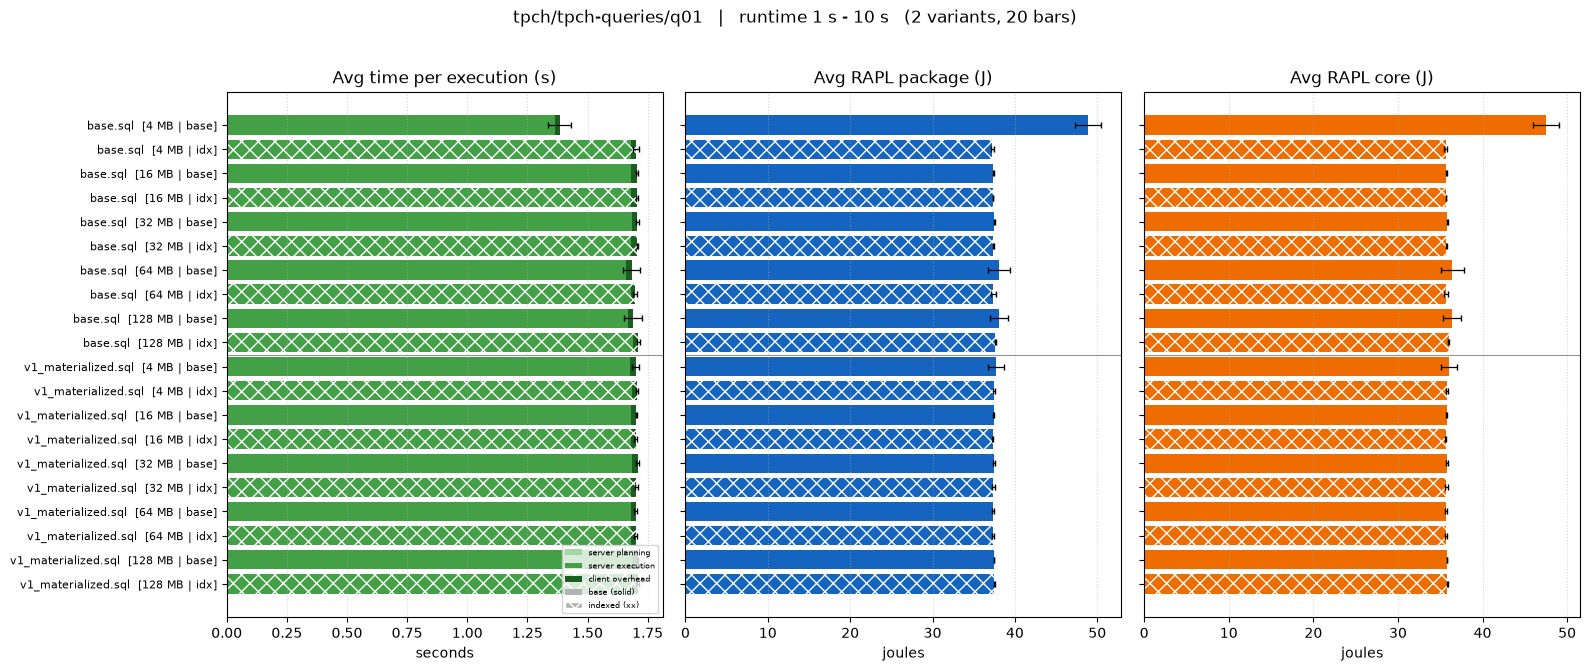

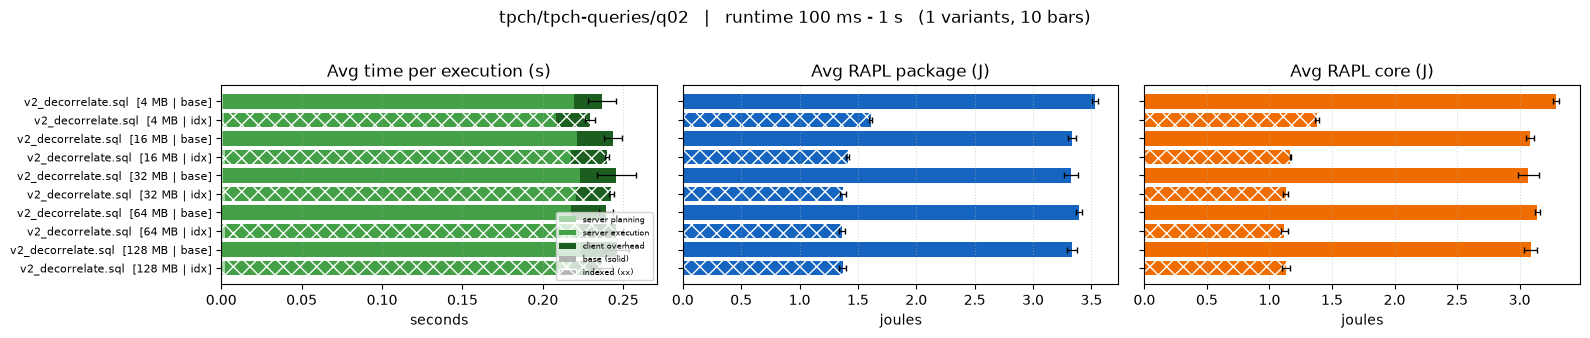

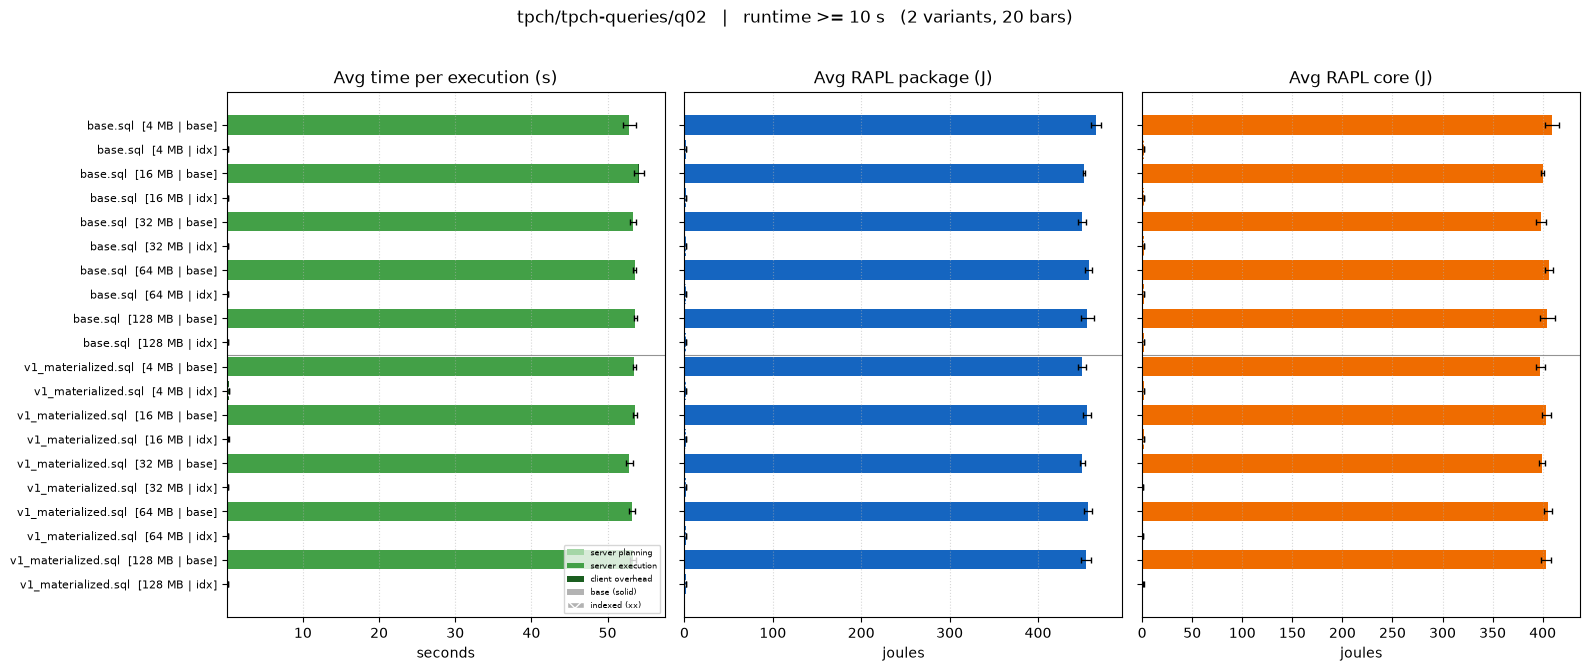

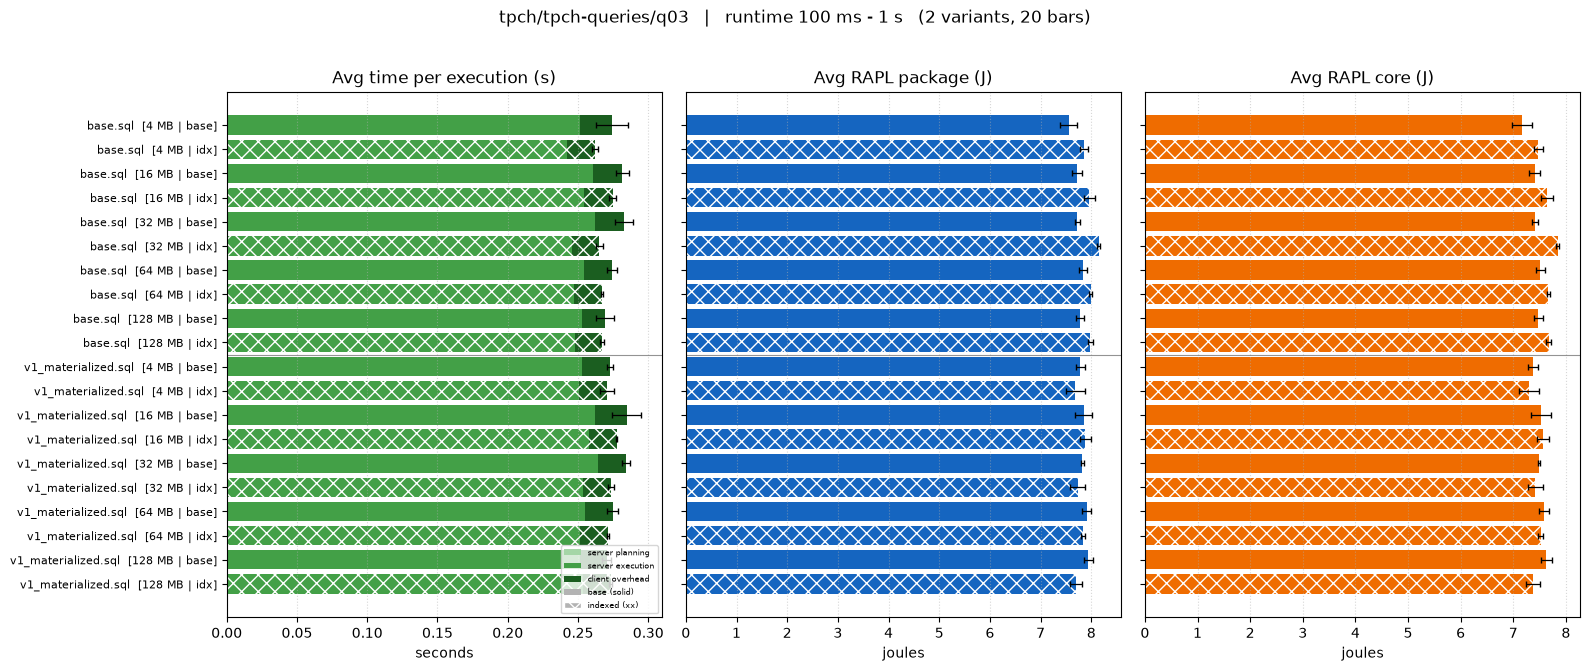

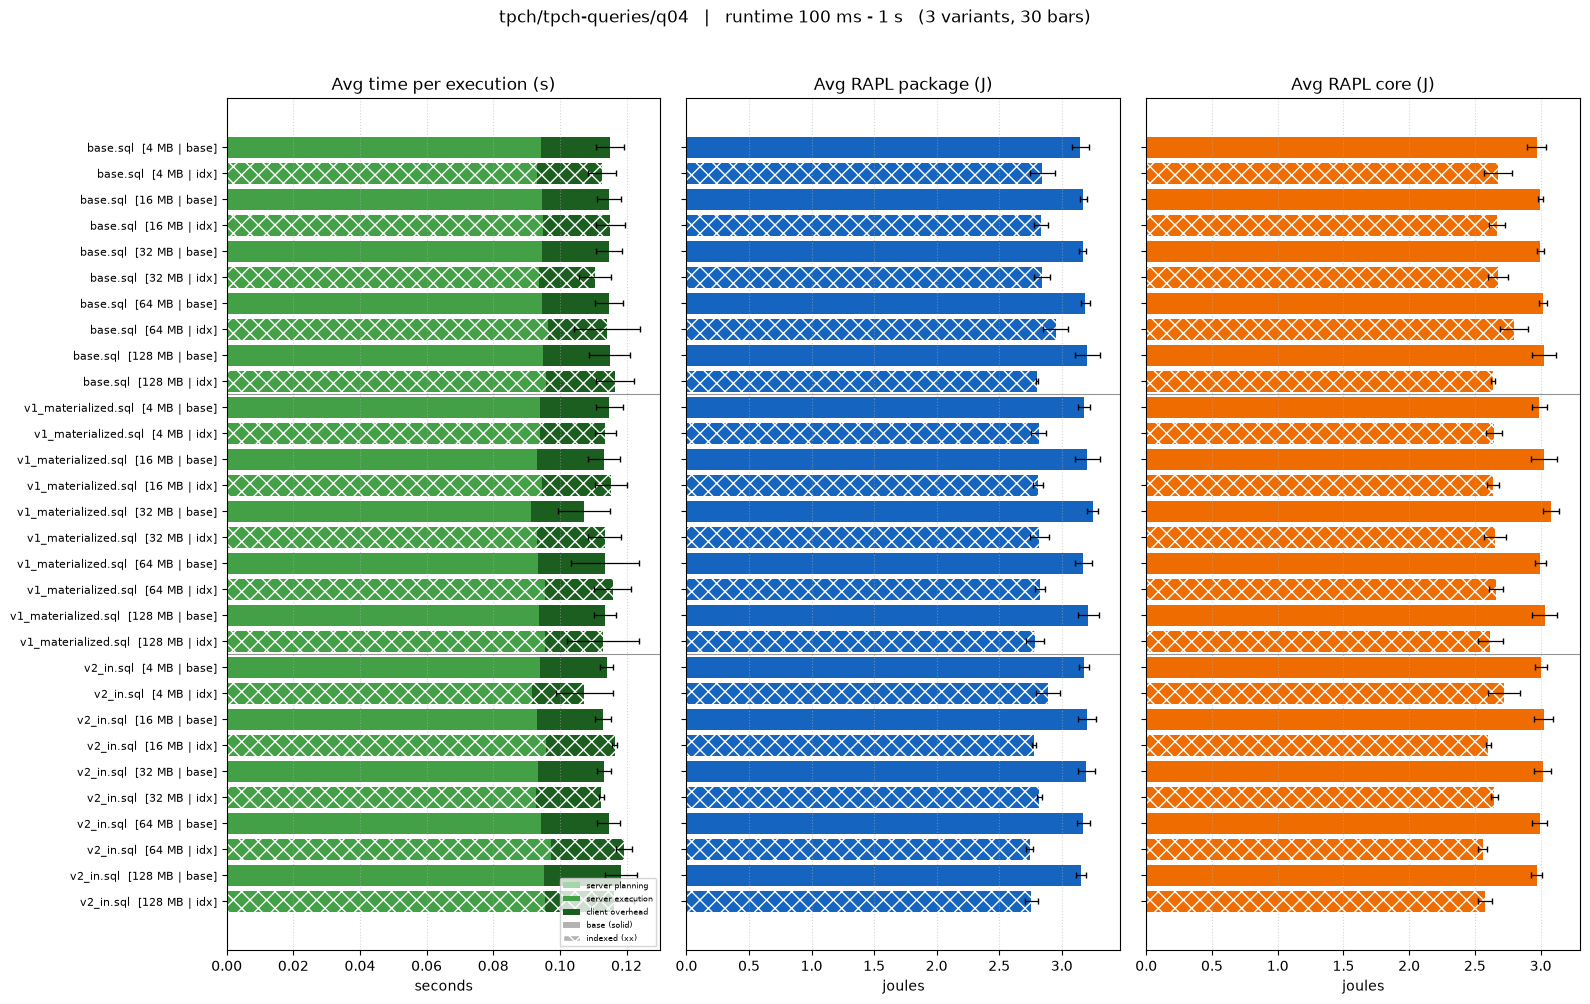

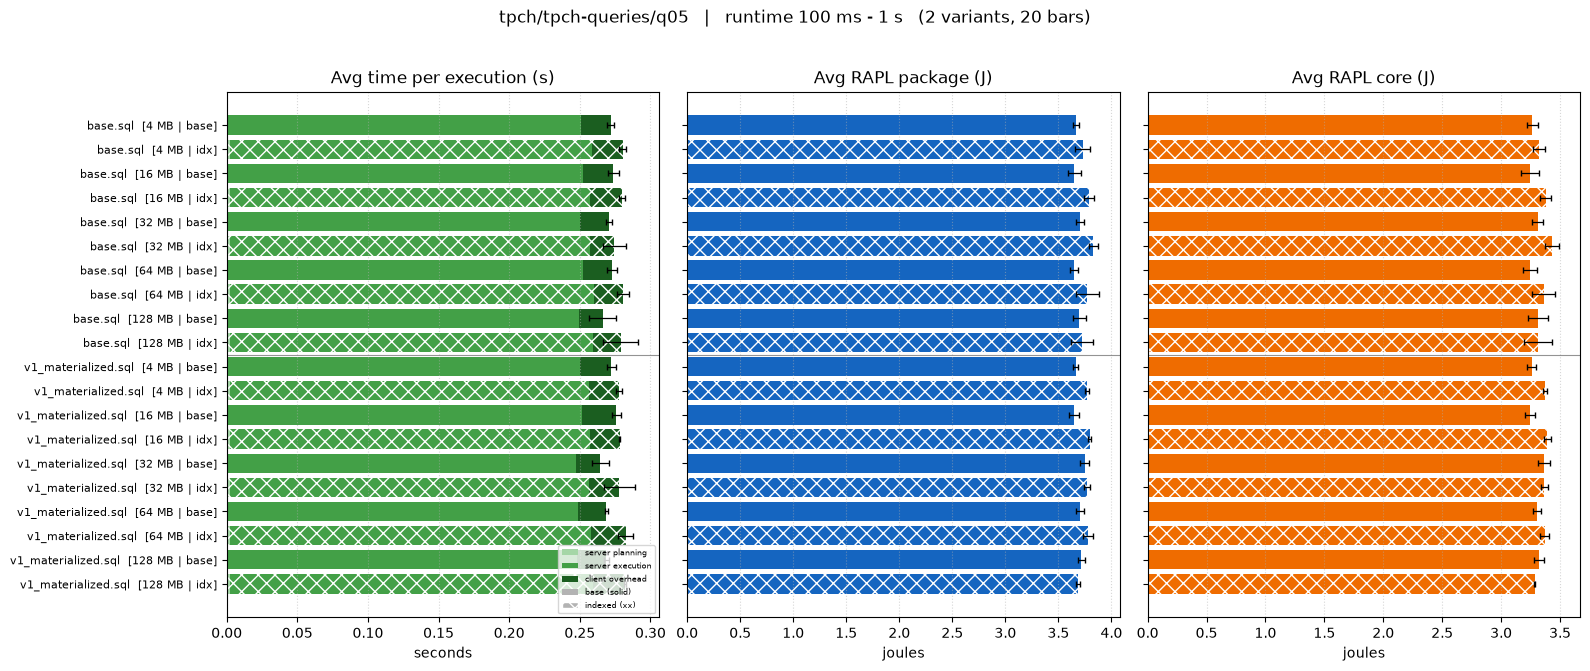

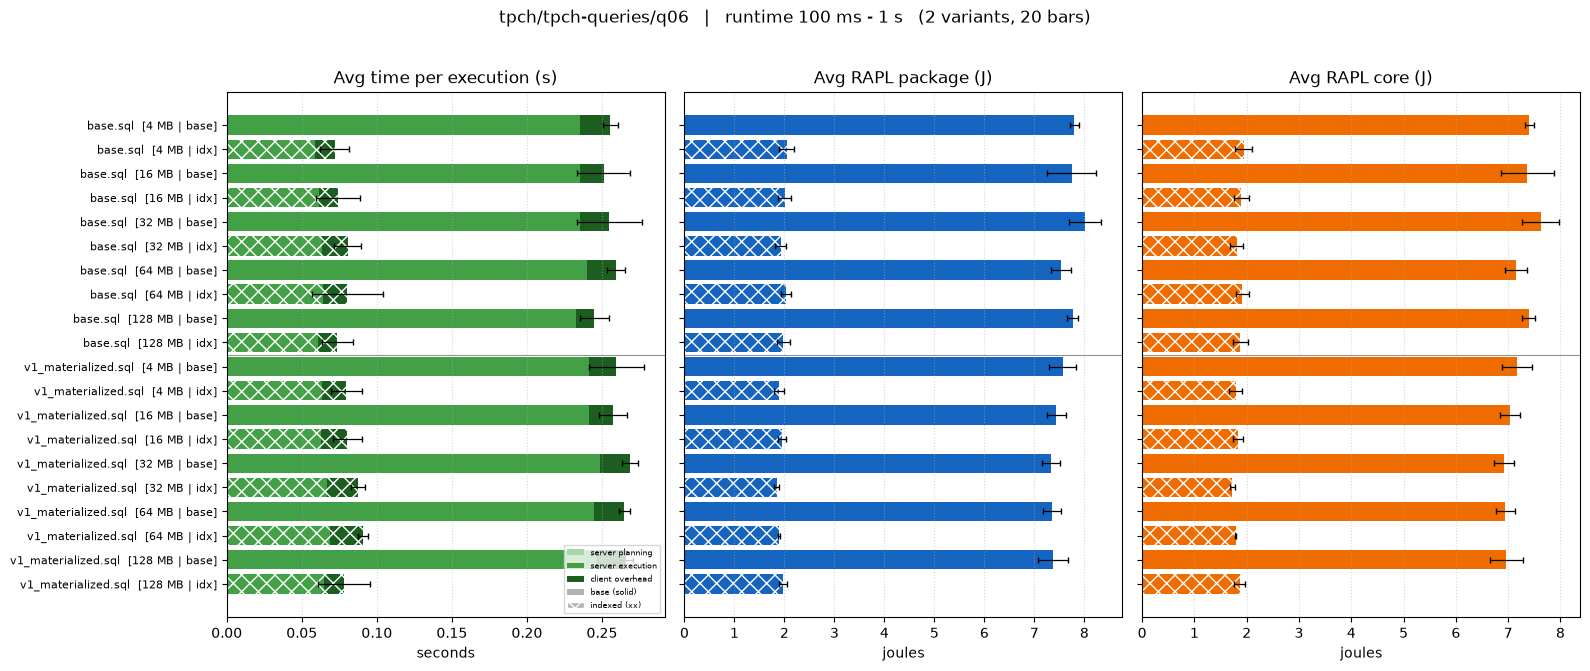

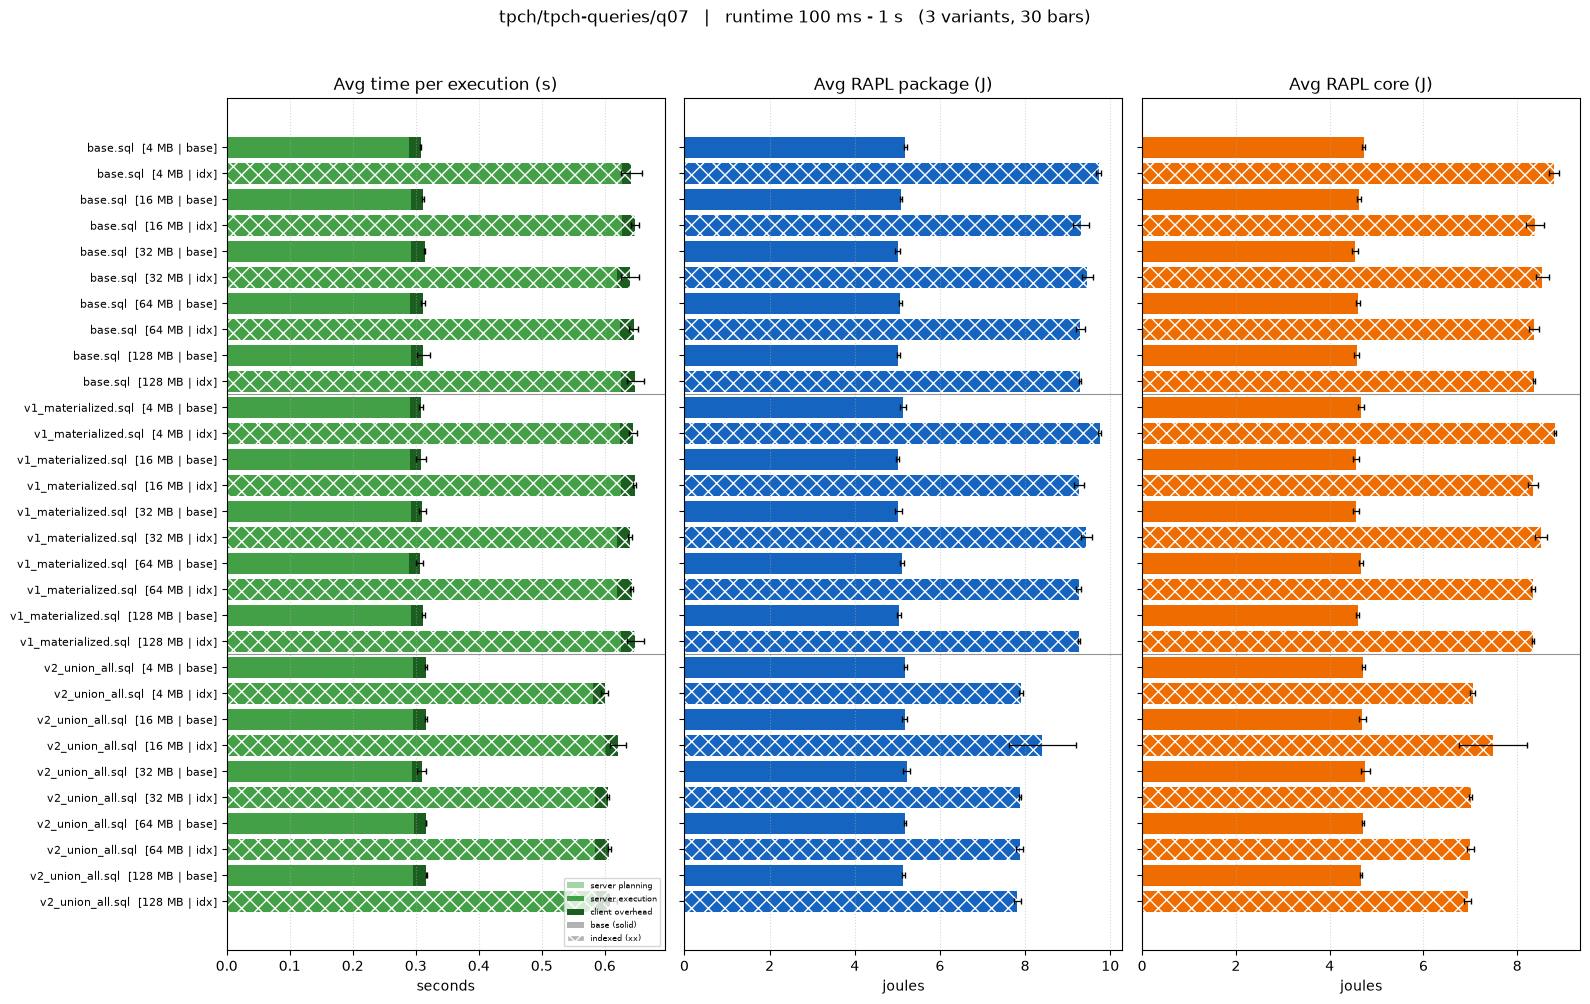

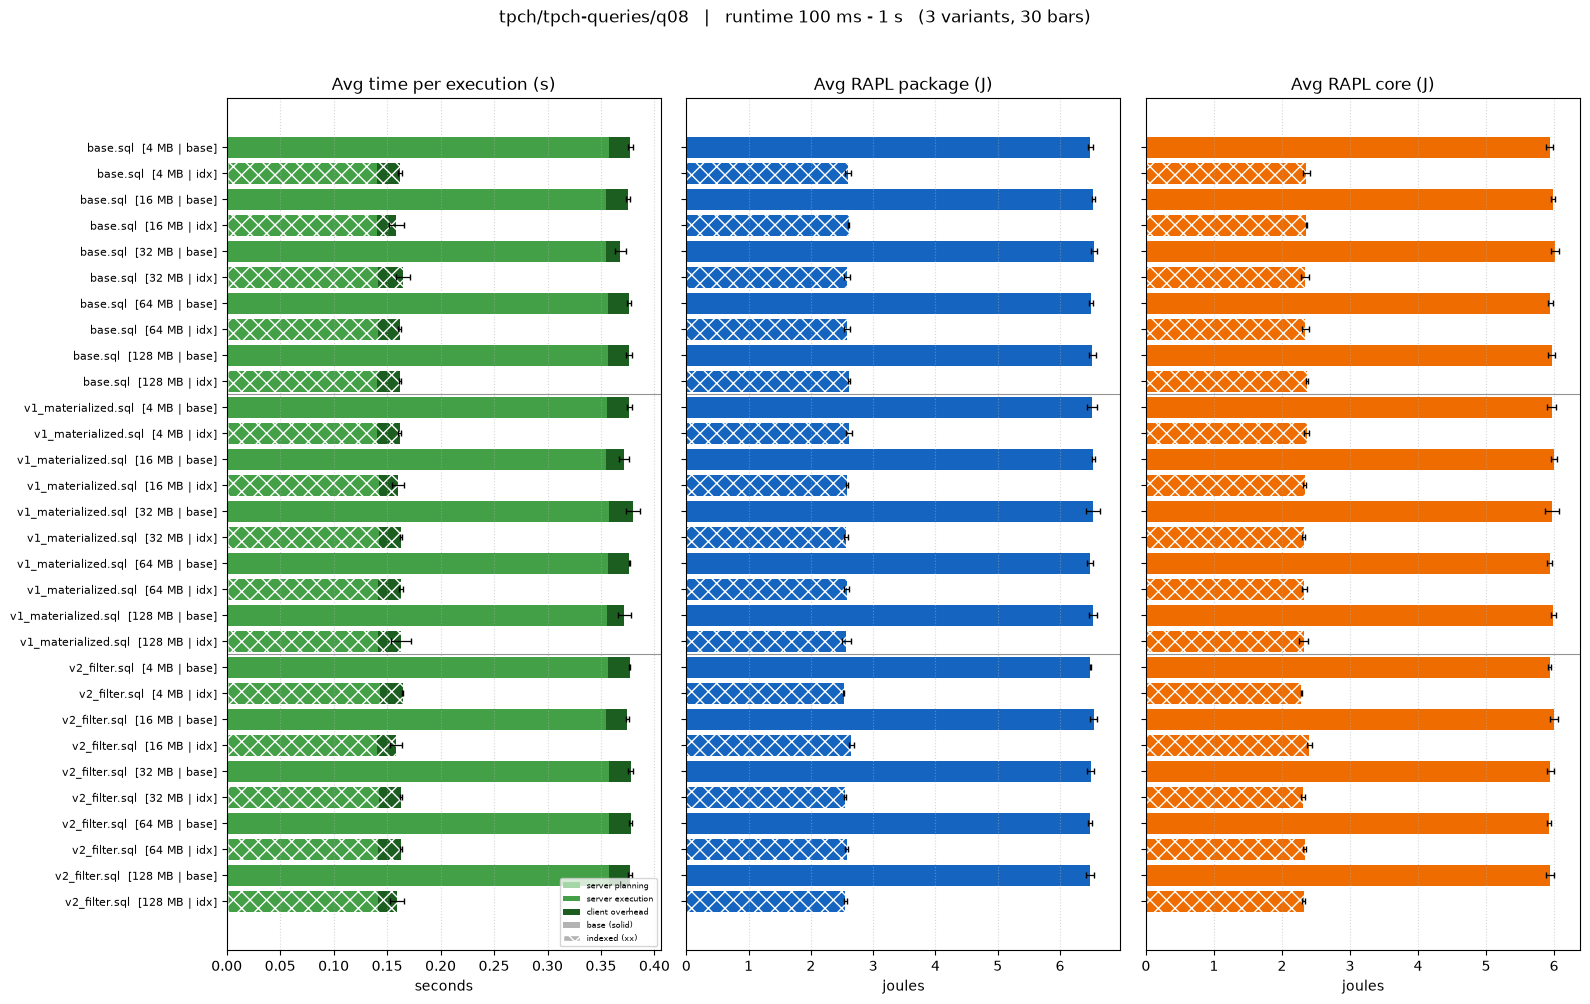

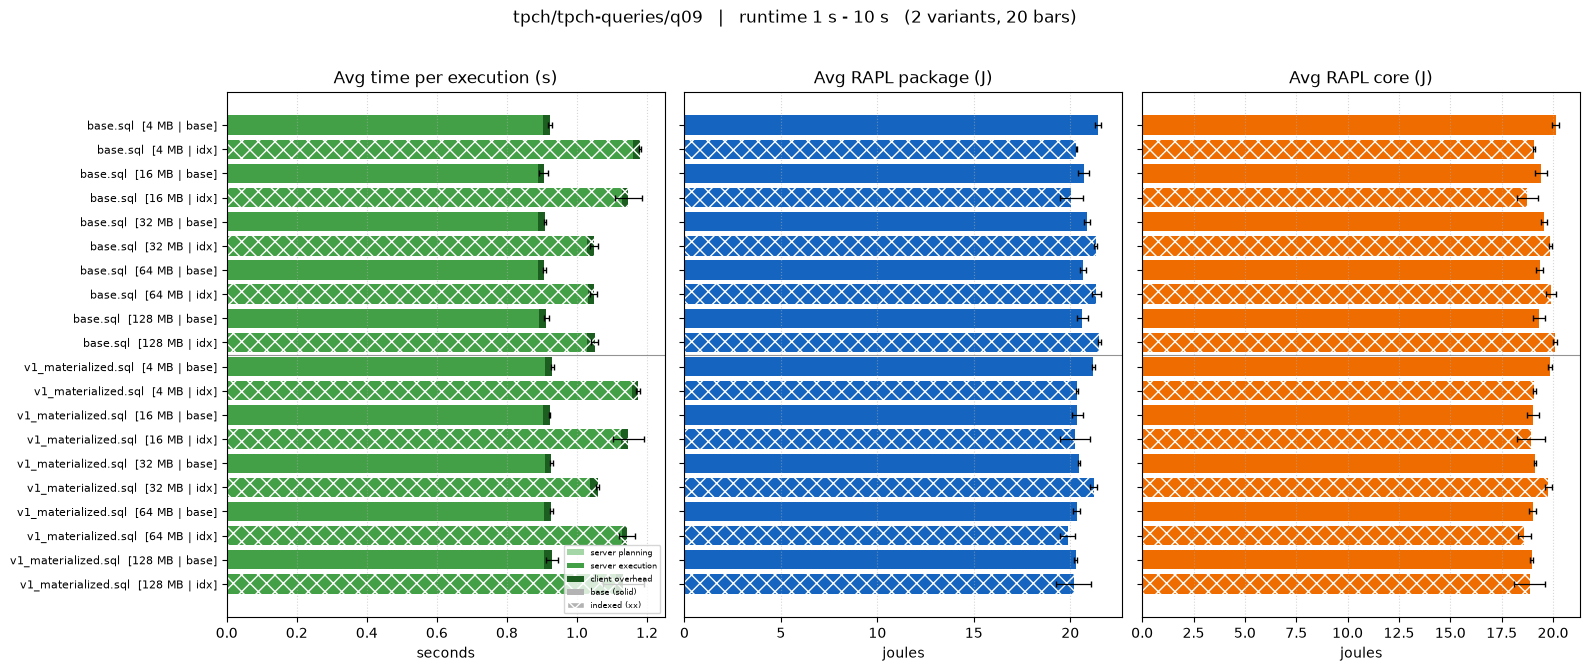

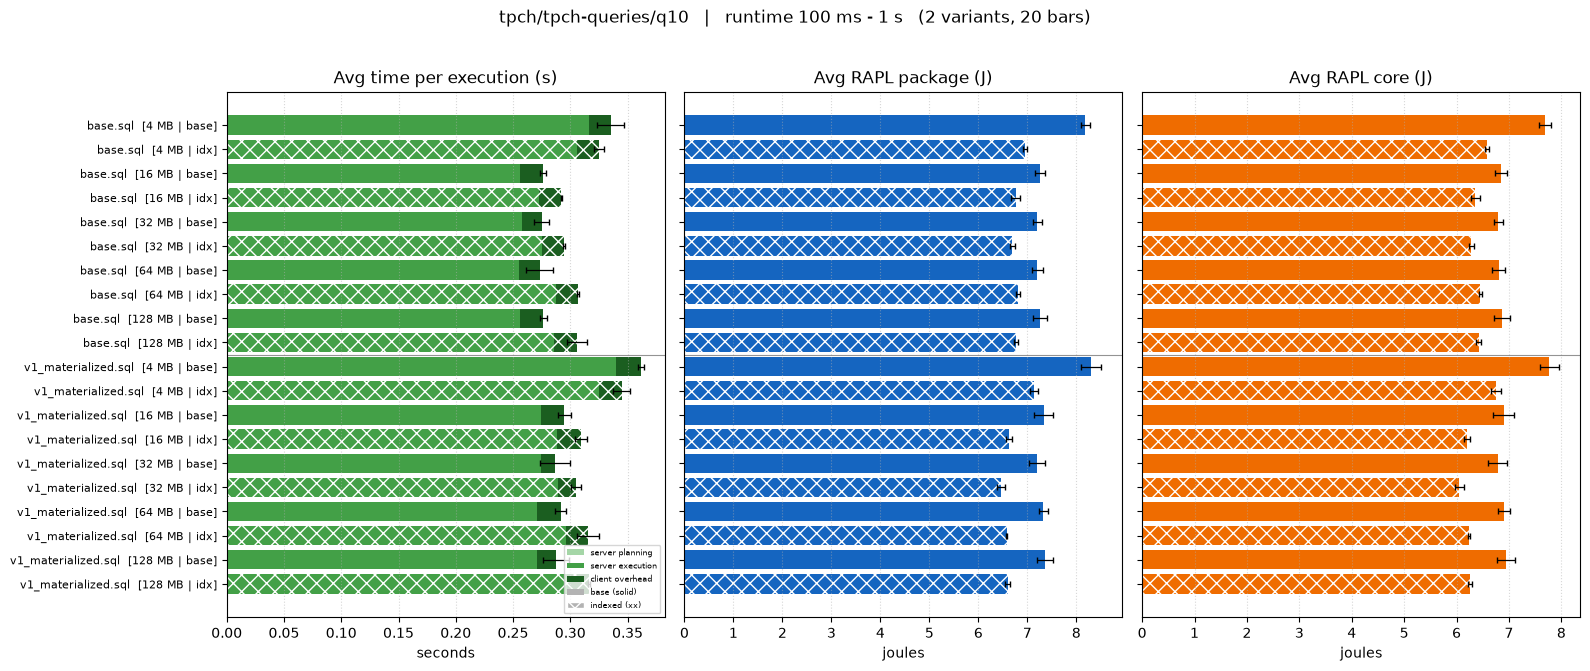

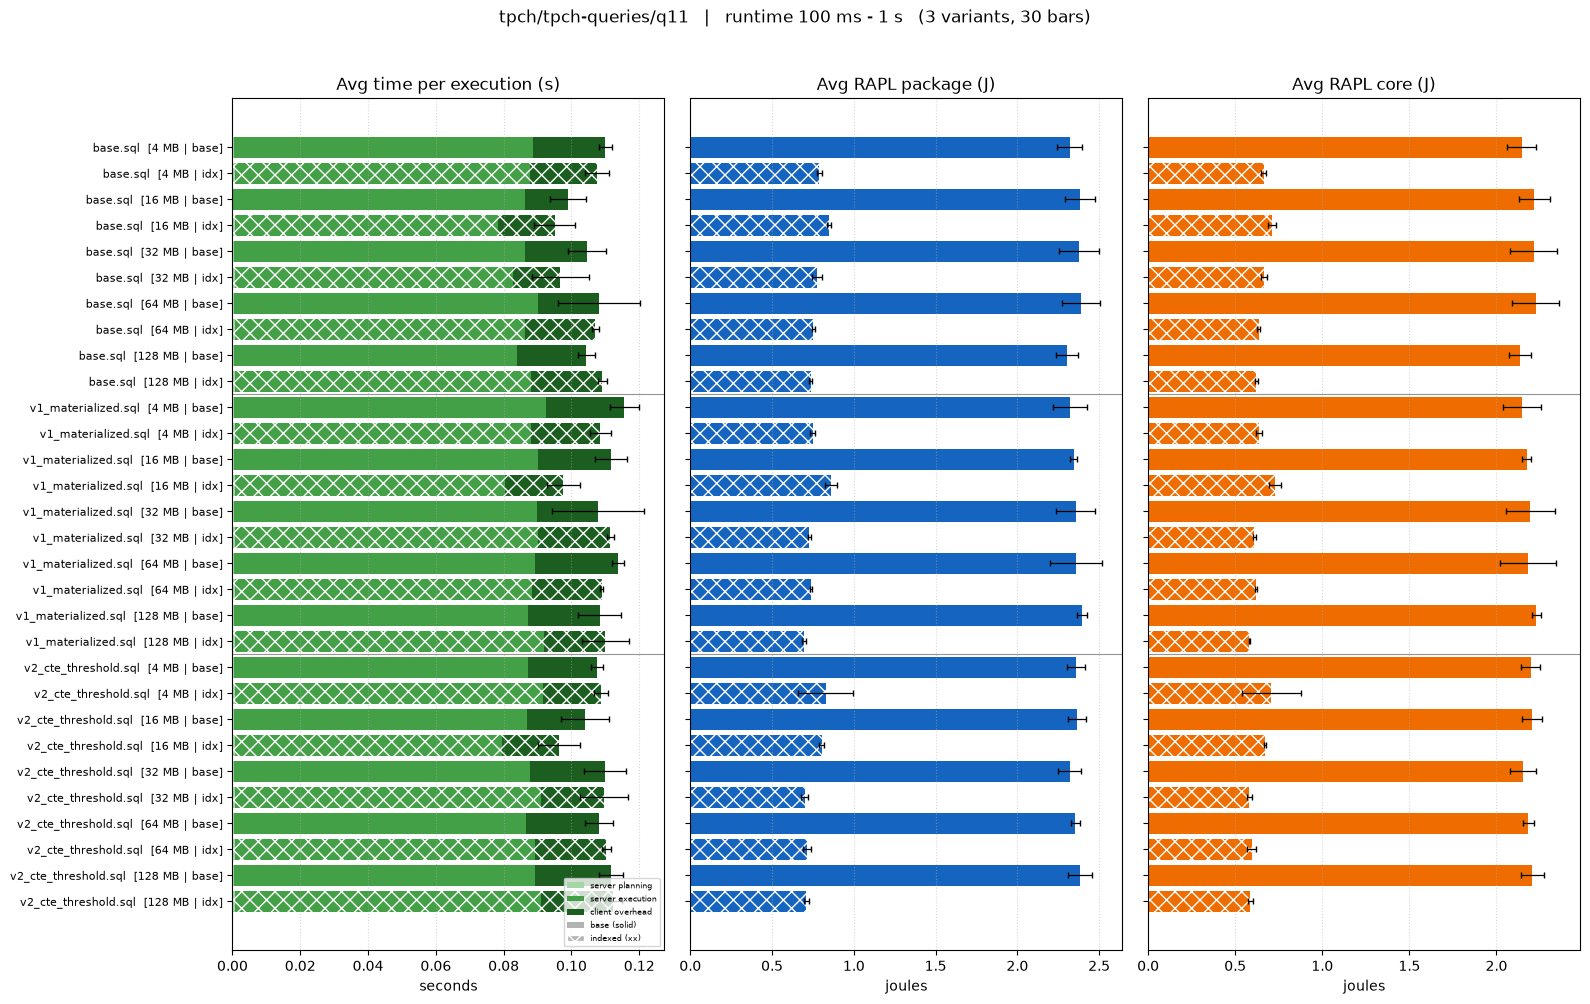

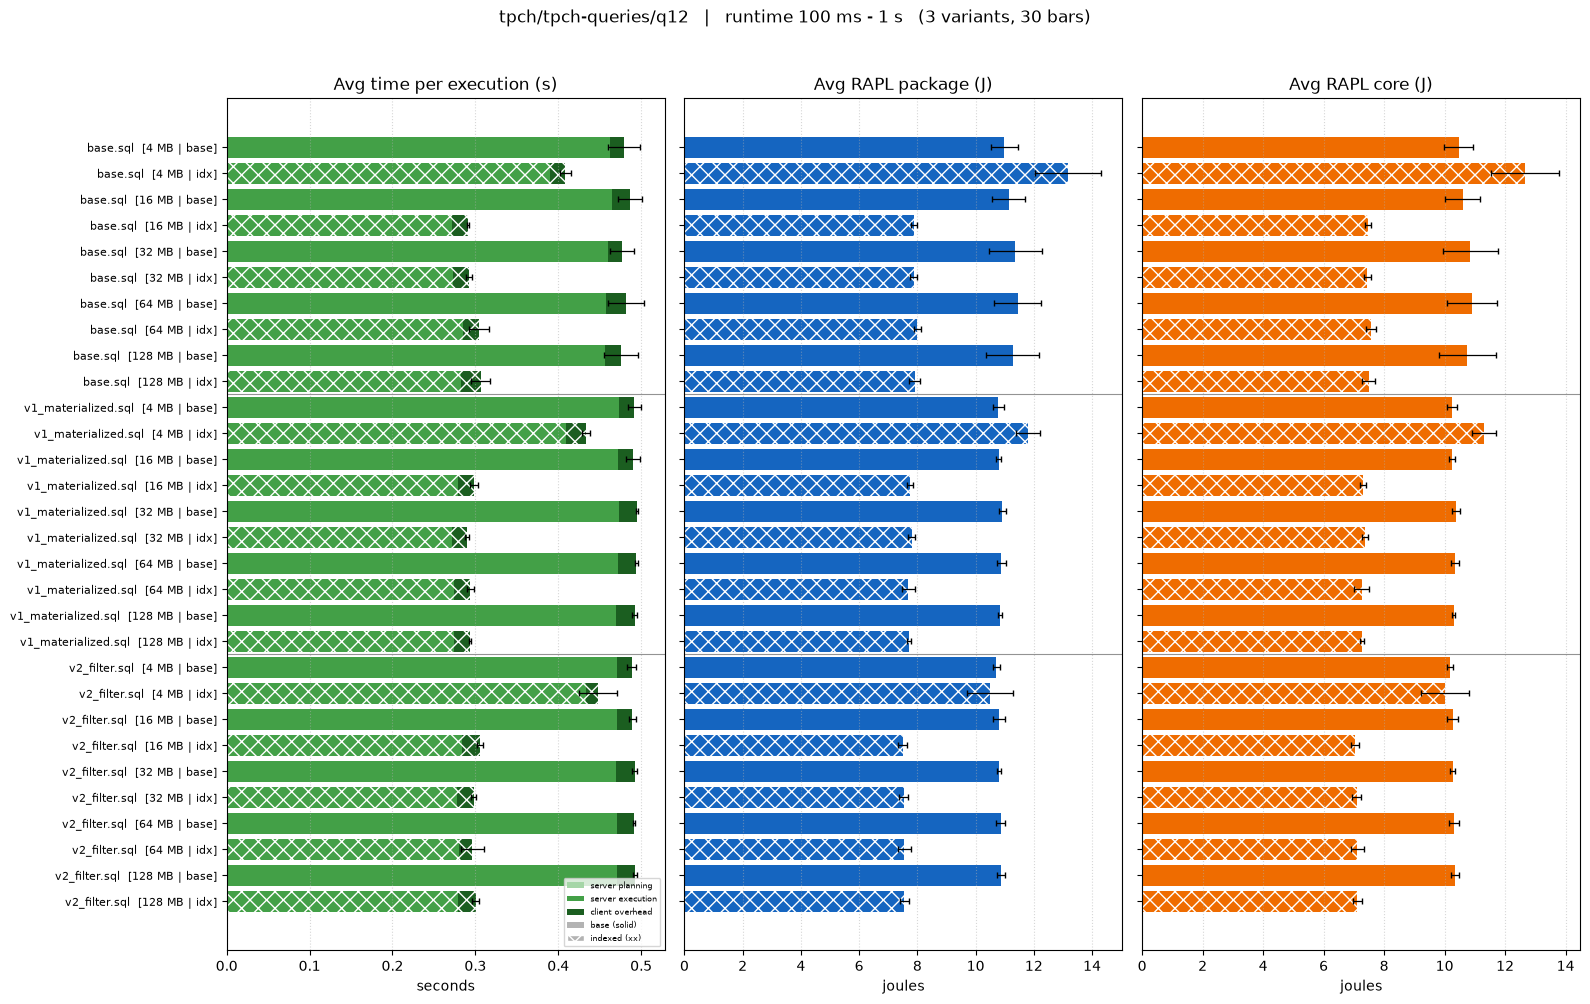

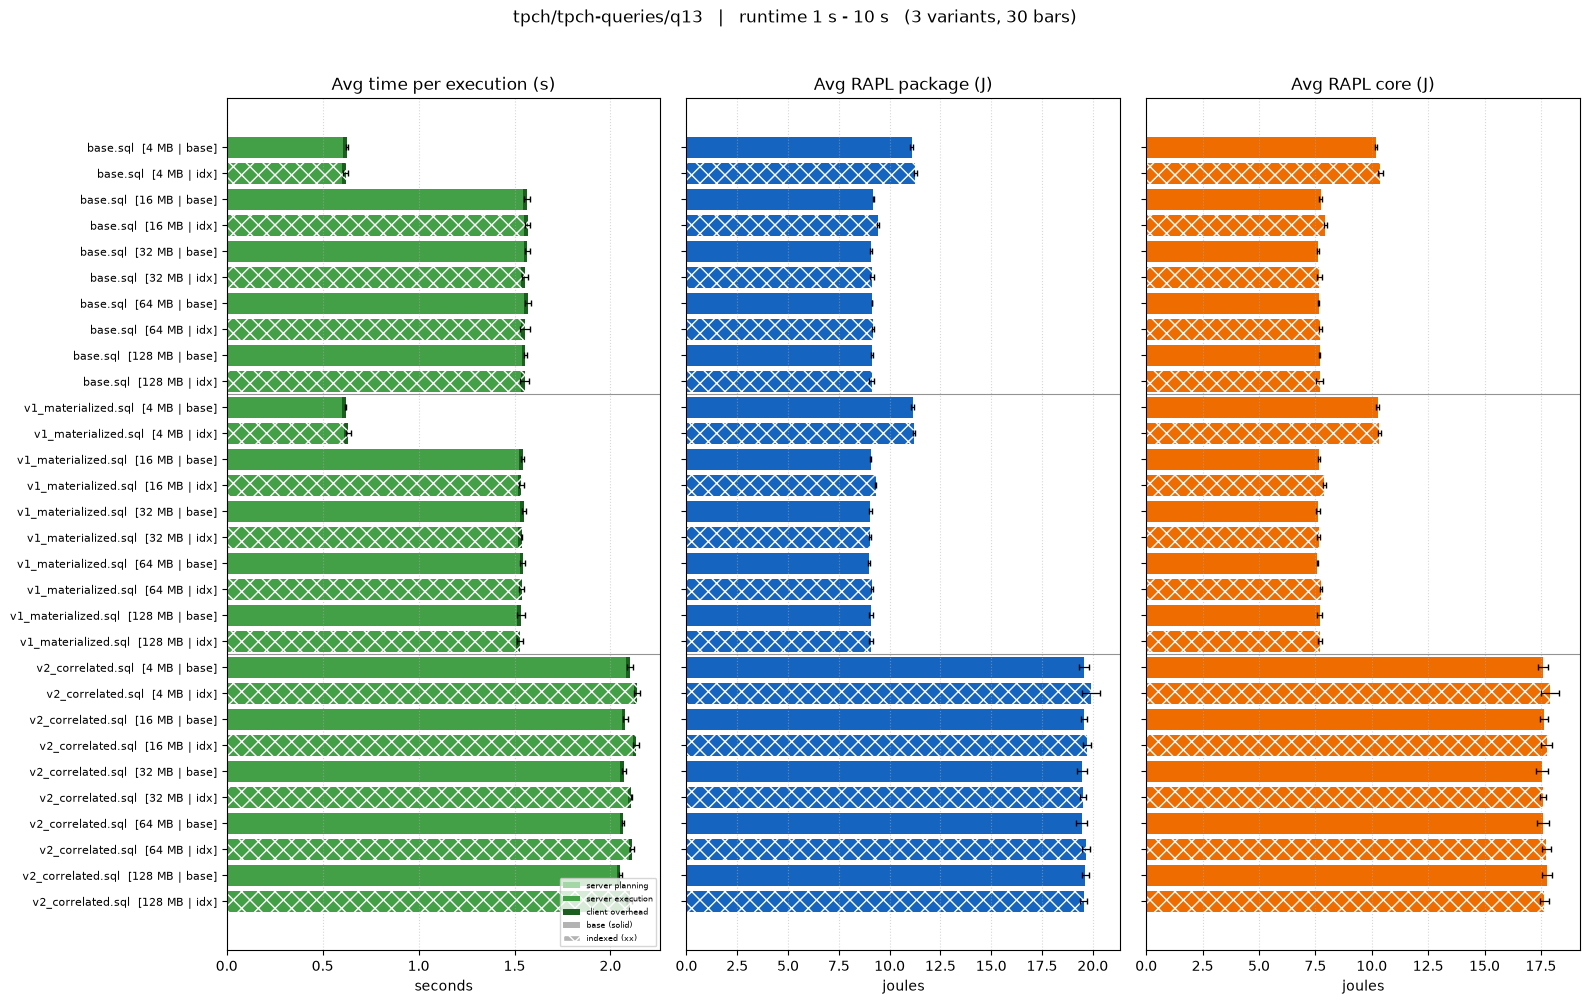

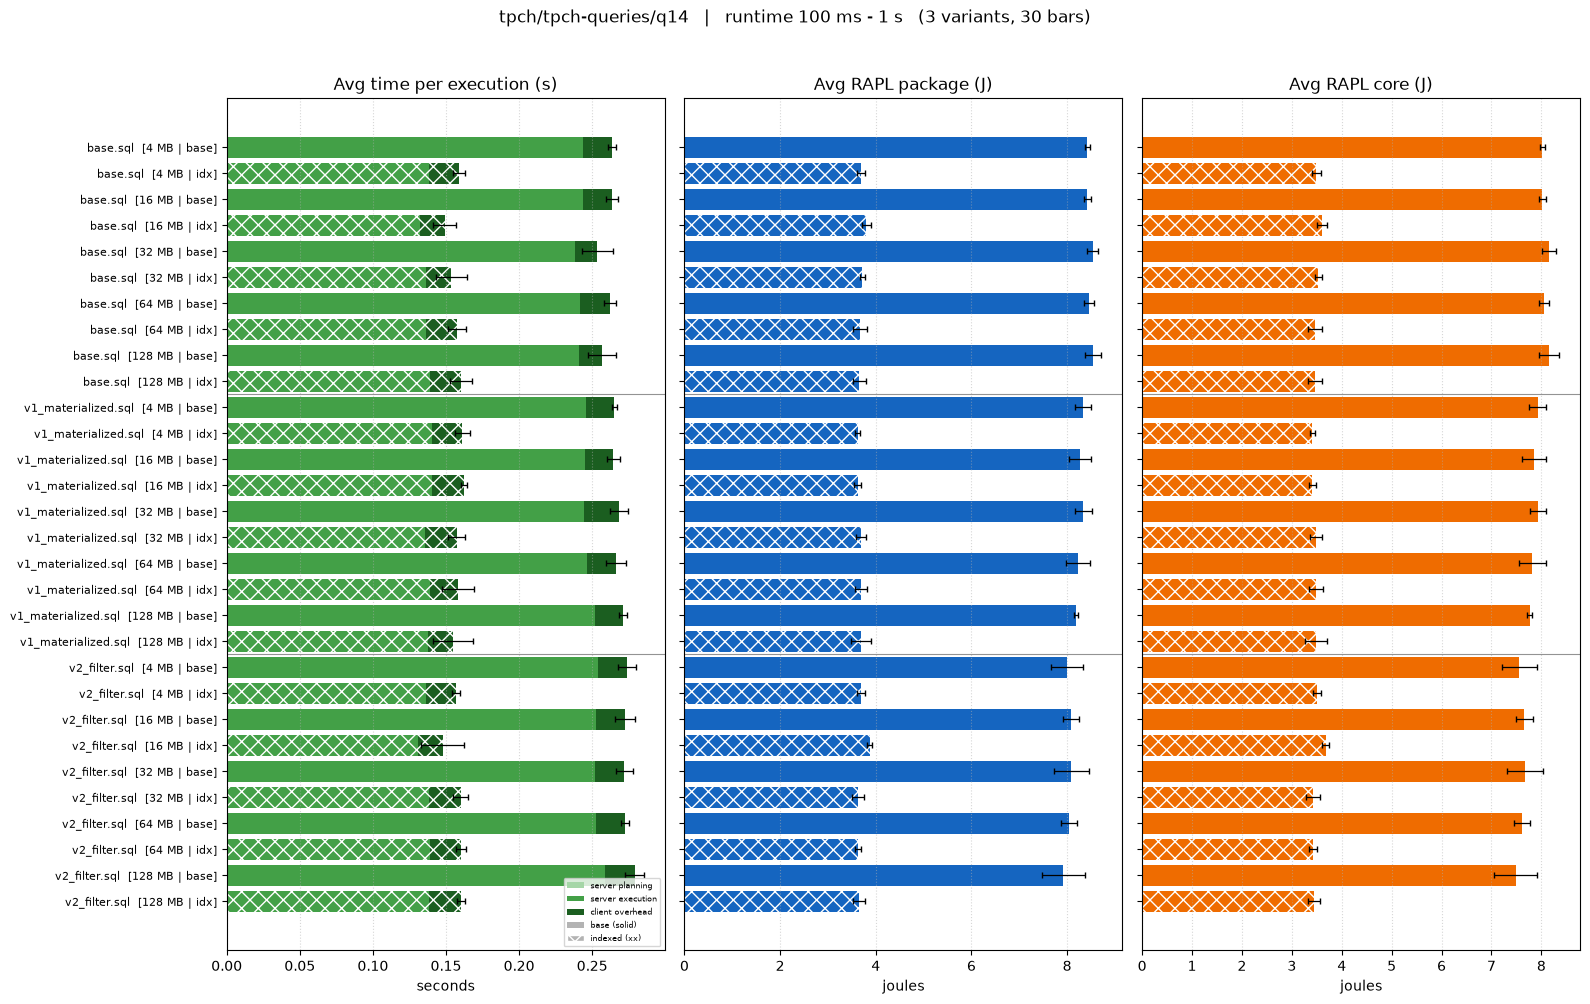

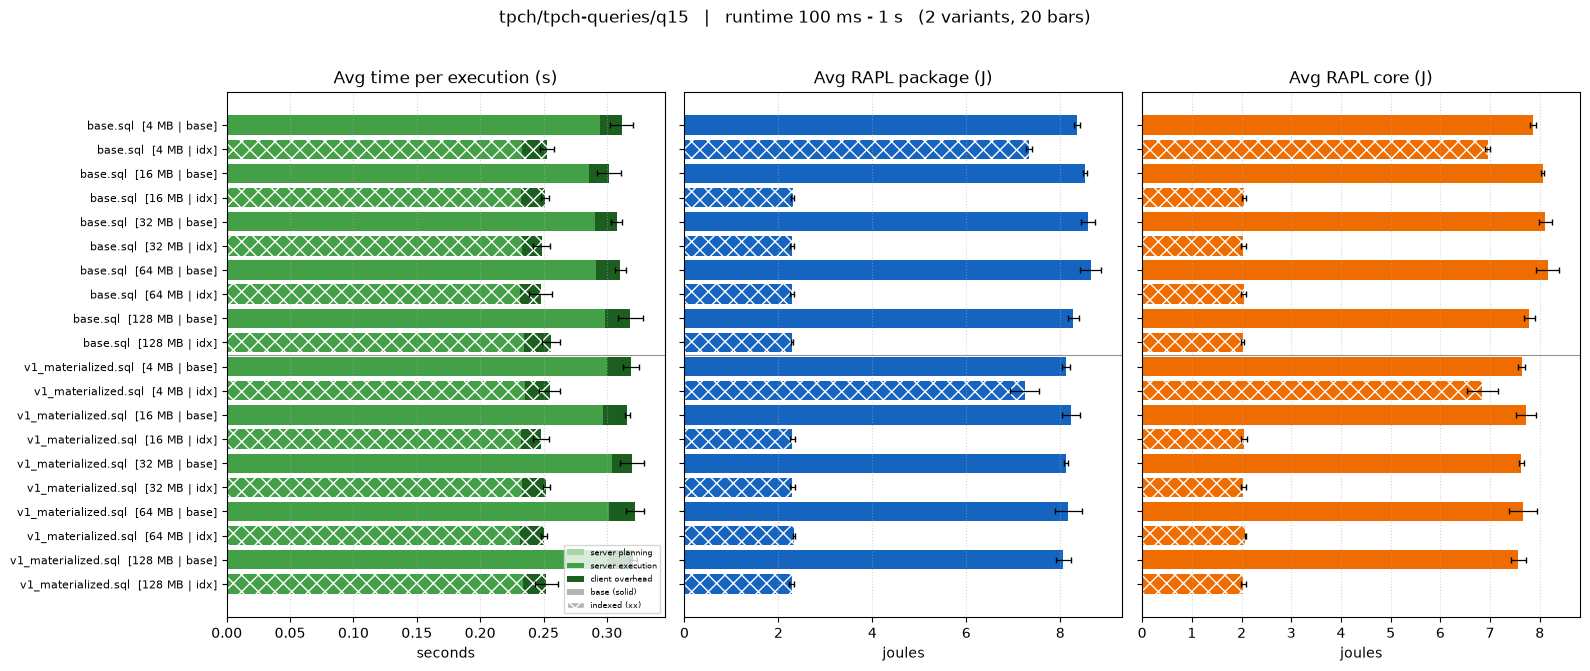

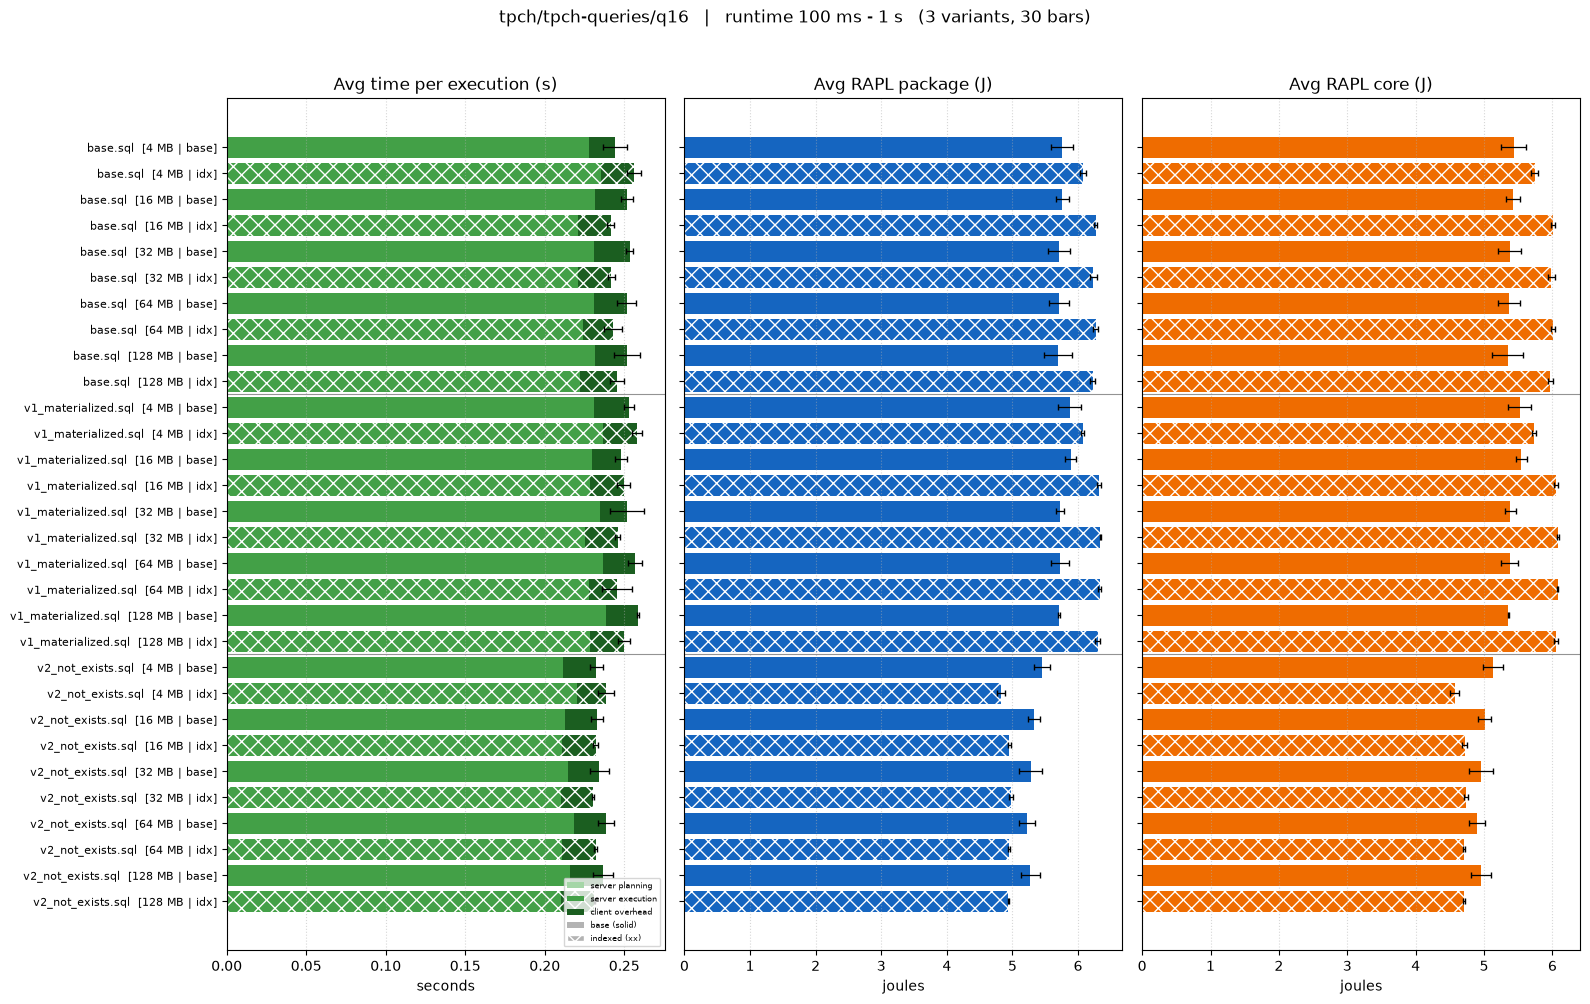

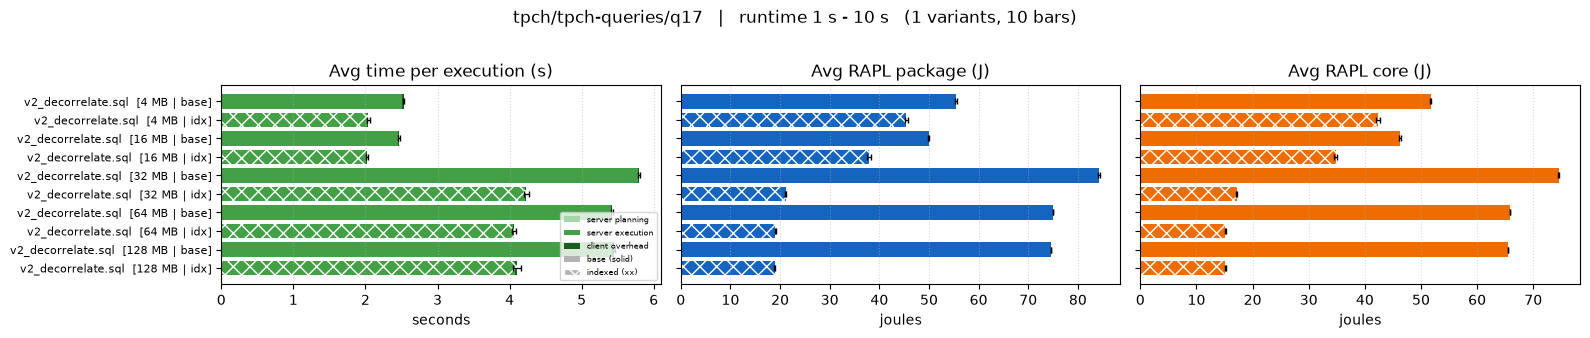

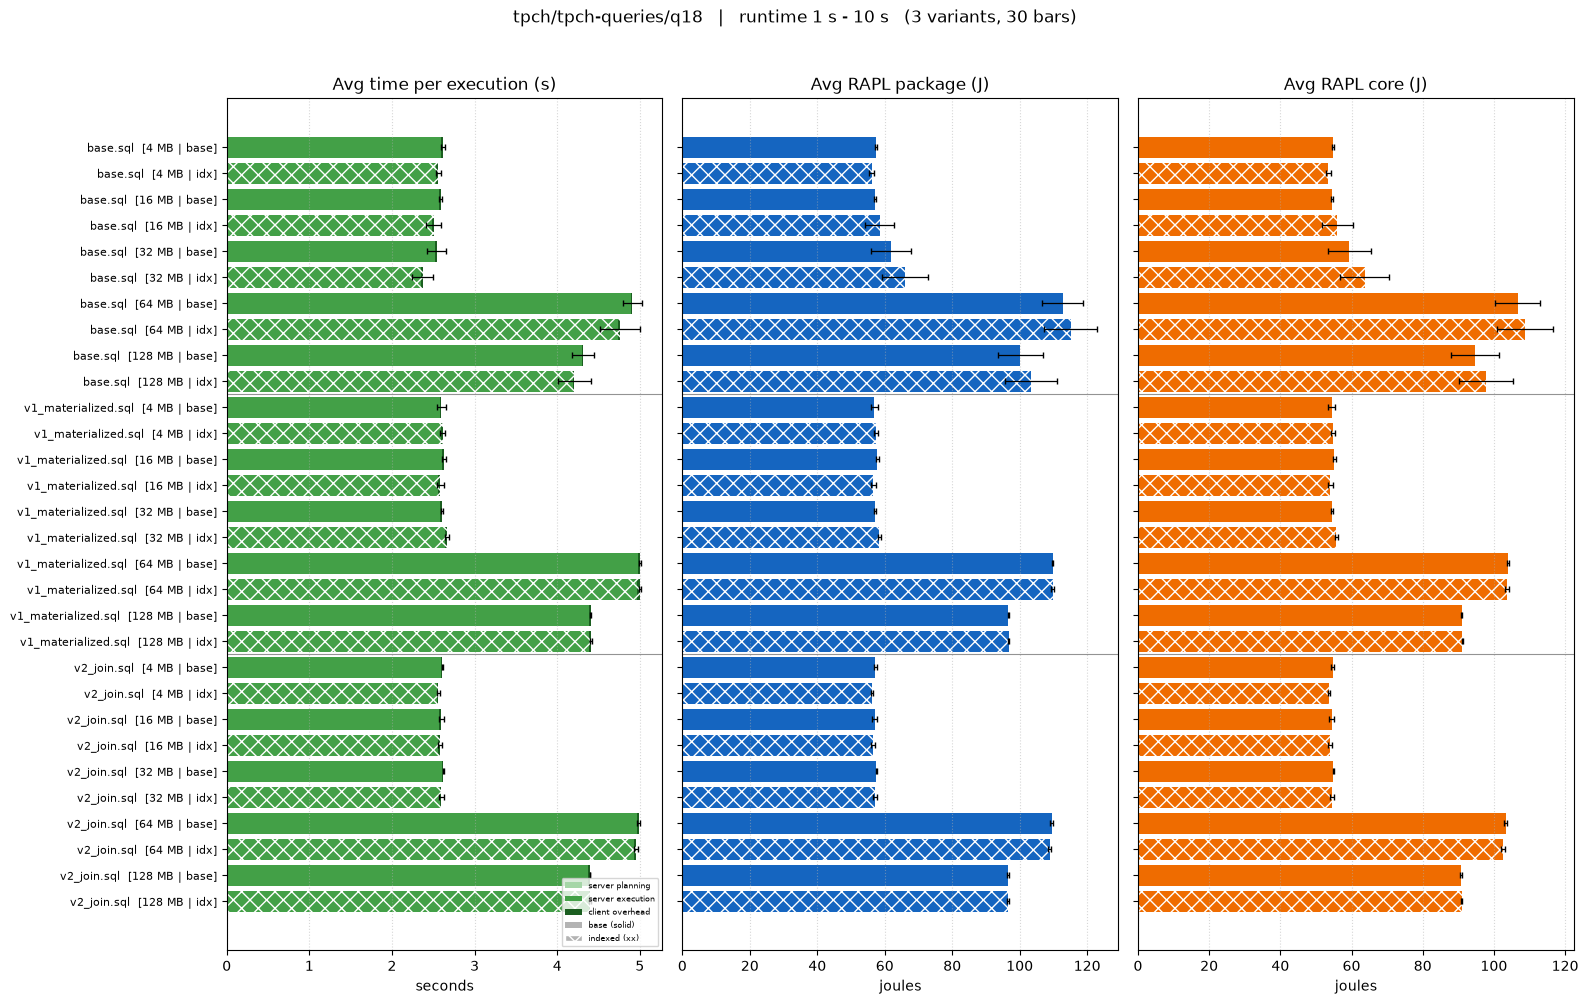

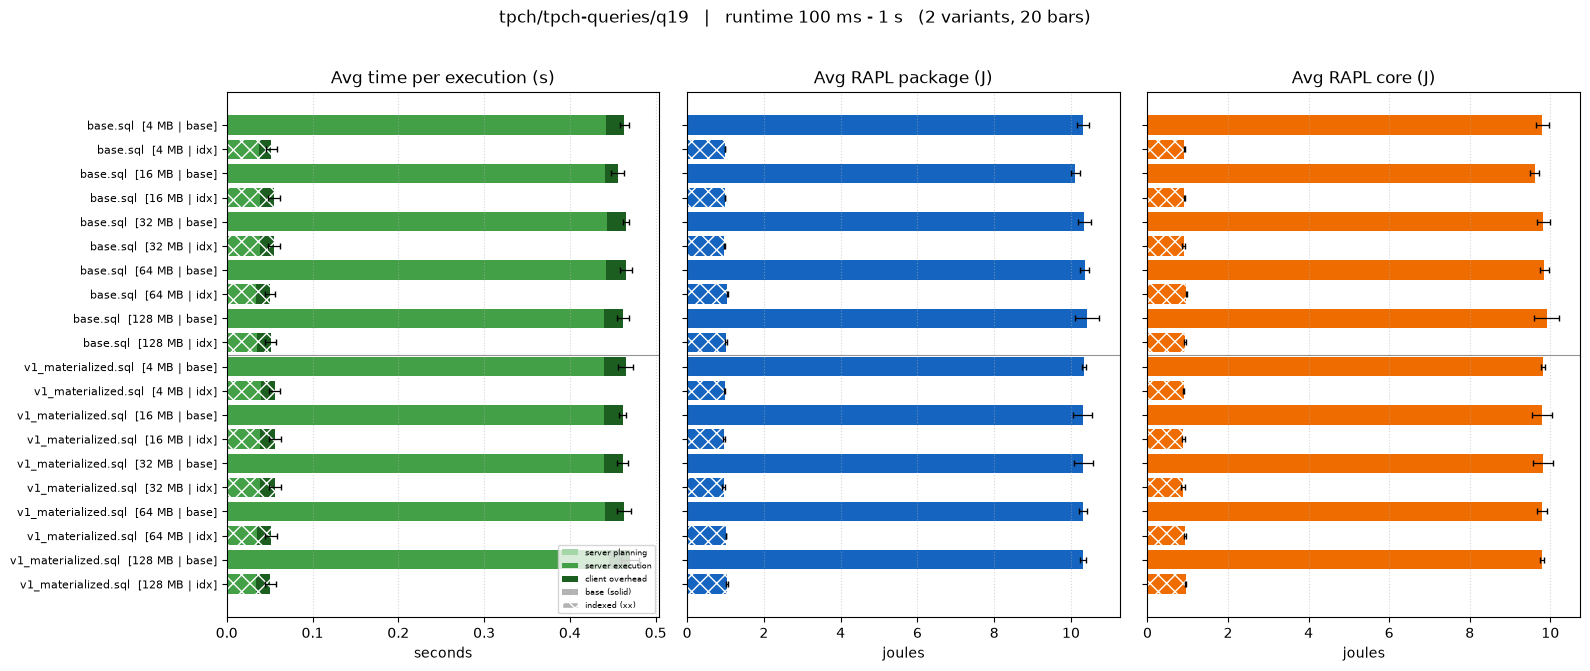

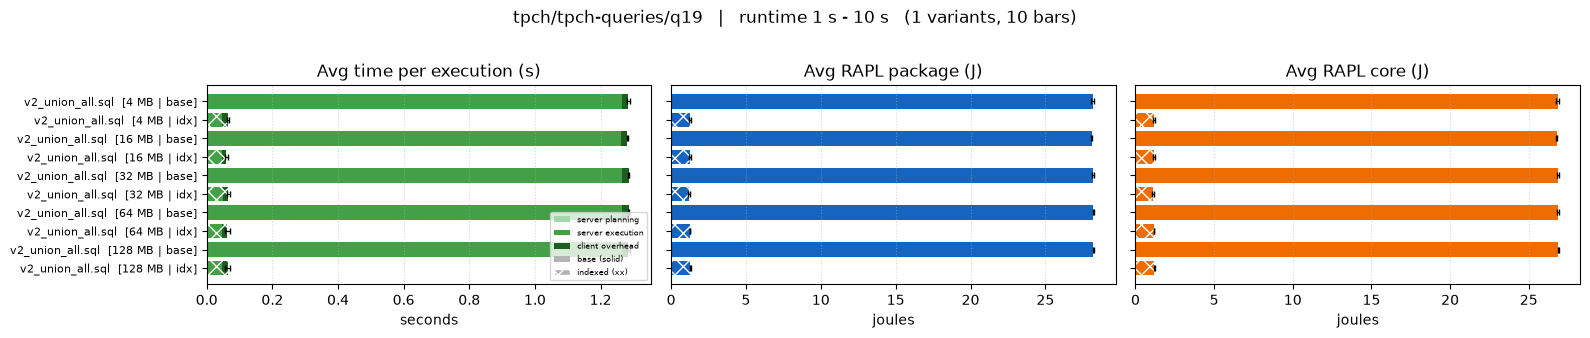

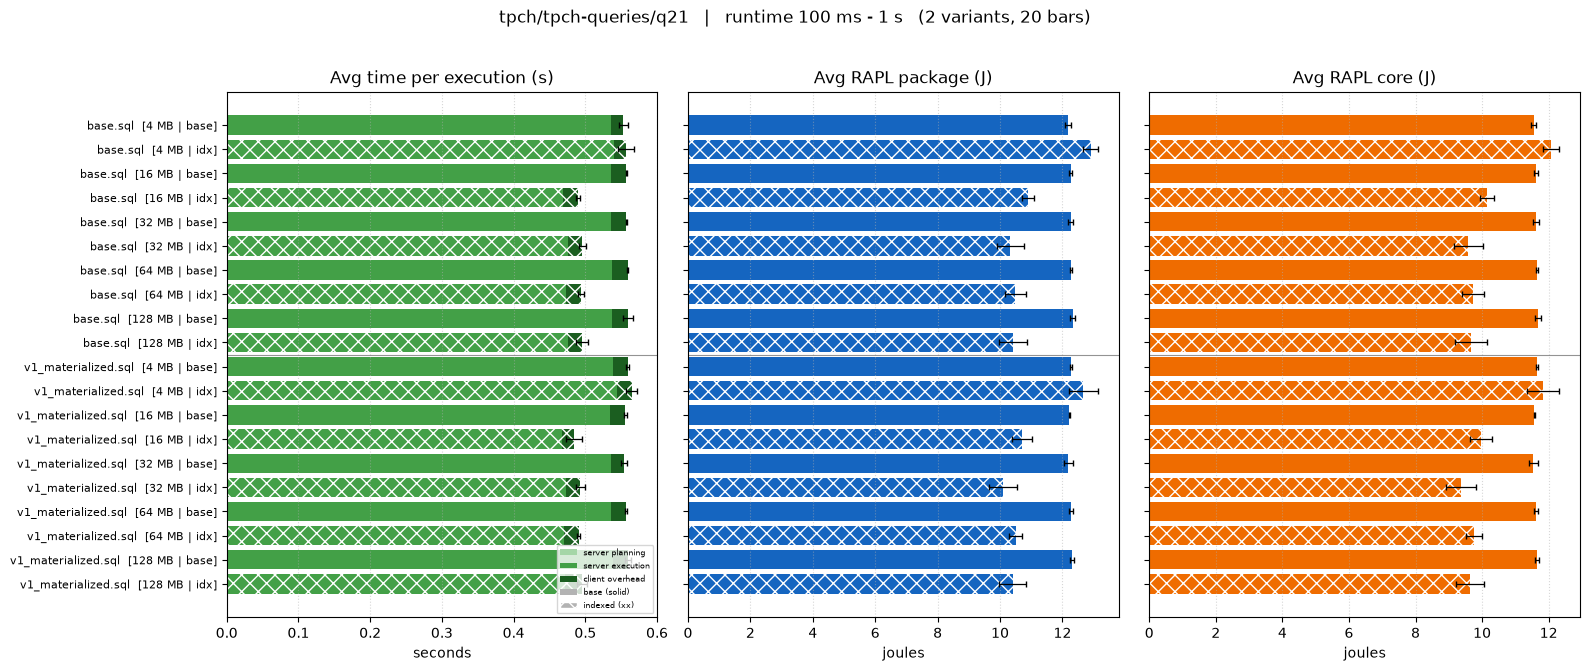

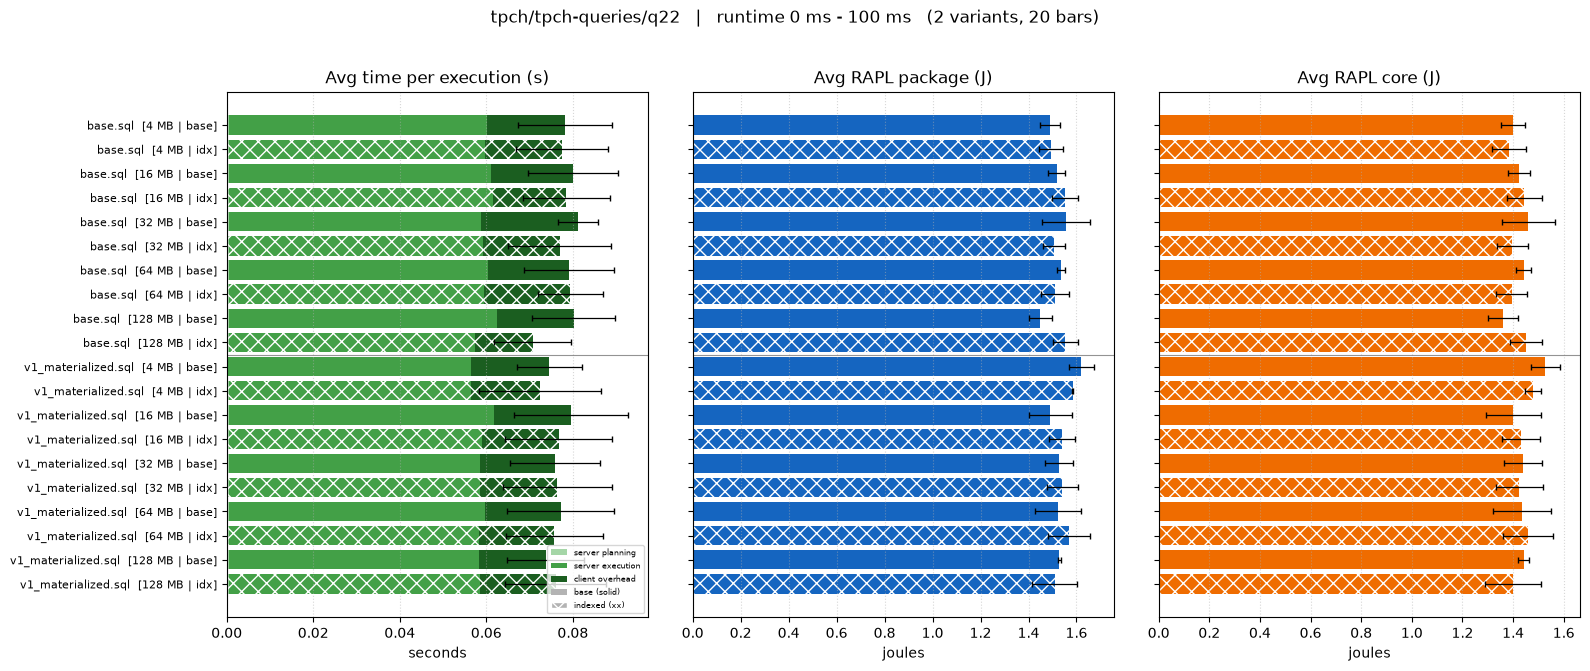

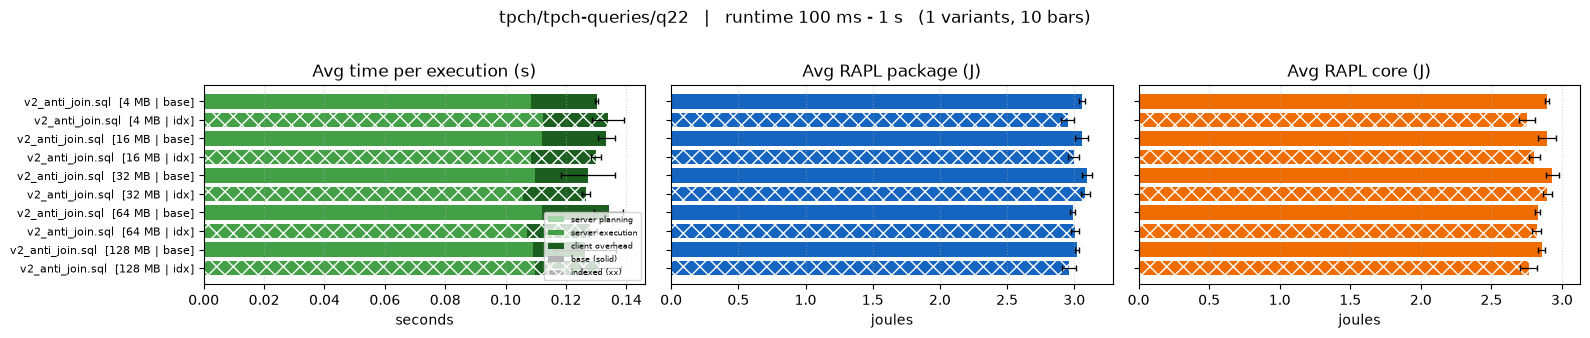

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

GROUPS = None                      # query folders to draw; None = all
RUNTIME_BINS = [0.0, 0.1, 1.0, 10.0]   # bin START values in seconds
BIN_STAT = "max"                   # "max" | "median" | "min" | "mean"
MAX_FIGURES = 250

COMPONENTS = [
    ("plan_s", "#a5d6a7", "server planning"),
    ("exec_s", "#43a047", "server execution"),
    ("overhead_s", "#1b5e20", "client overhead"),
]
IDX_HATCH = "xx"
edges = list(RUNTIME_BINS) + [np.inf]


def fmt_t(s):
    return f"{s * 1000:g} ms" if s < 1 else f"{s:g} s"


def bin_name(i):
    lo, hi = edges[i], edges[i + 1]
    return f">= {fmt_t(lo)}" if np.isinf(hi) else f"{fmt_t(lo)} - {fmt_t(hi)}"


all_groups = sorted(data["group"].dropna().unique())
groups = all_groups if GROUPS is None else [g for g in all_groups if g in GROUPS]

qrep = data.groupby("query")["avg_time_s"].agg(BIN_STAT)
qbin = pd.Series(np.digitize(qrep.to_numpy(), edges[1:], right=False),
                 index=qrep.index)
qbin[qrep.isna()] = -1
dq = data.copy()
dq["_bin"] = dq["query"].map(qbin)
dq["_idx_ord"] = (dq["index_status"] == "idx").astype(int)
dq["plab"] = (dq["sql_file"] + "  [" + dq["plabel"]
              + " | " + dq["index_status"] + "]")

tasks = []
for group in groups:
    gb = dq.loc[dq["group"] == group, "_bin"]
    for i in sorted(b for b in gb.dropna().unique() if b >= 0):
        tasks.append((group, int(i)))
print(f"{len(groups)} query folder(s) -> {len(tasks)} figures")
if len(tasks) > MAX_FIGURES:
    print(f"capping to {MAX_FIGURES}")
    tasks = tasks[:MAX_FIGURES]


def hatch_idx(container, is_idx):
    for bar, ix in zip(container, is_idx):
        if ix:
            bar.set_hatch(IDX_HATCH)
            bar.set_edgecolor("white")
            bar.set_linewidth(0.0)


for group, i in tasks:
    g = dq[(dq["group"] == group) & (dq["_bin"] == i)].copy()
    g = g.sort_values(["sql_file", "pval", "_idx_ord"])
    y = np.arange(len(g))
    is_idx = (g["index_status"] == "idx").to_numpy()
    height = max(1.8, len(g) * 0.34)
    fig, axes = plt.subplots(1, 3, figsize=(16, height), sharey=True)

    ax = axes[0]
    left = np.zeros(len(g))
    for col, colour, _ in COMPONENTS:
        hatch_idx(ax.barh(y, g[col].fillna(0).to_numpy(dtype=float),
                          left=left, color=colour), is_idx)
        left += g[col].fillna(0).to_numpy(dtype=float)
    std = g["time_std"].to_numpy(dtype=float)
    ok = ~np.isnan(std)
    if ok.any():
        ax.errorbar(left[ok], y[ok], xerr=std[ok], fmt="none",
                    ecolor="black", elinewidth=0.9, capsize=2)
    ax.set_title("Avg time per execution (s)"); ax.set_xlabel("seconds")
    handles = [Patch(facecolor=c, label=l) for _, c, l in COMPONENTS]
    handles += [Patch(facecolor="0.7", label="base (solid)"),
                Patch(facecolor="0.7", hatch=IDX_HATCH, edgecolor="white",
                      label="indexed (xx)")]
    ax.legend(handles=handles, fontsize=6, loc="lower right")

    for ax, col, scol, colour, title in (
        (axes[1], "avg_pkg_j", "pkg_j_std", "#1565c0", "Avg RAPL package (J)"),
        (axes[2], "avg_core_j", "core_j_std", "#ef6c00", "Avg RAPL core (J)"),
    ):
        vals = g[col].to_numpy(dtype=float)
        hatch_idx(ax.barh(y, np.nan_to_num(vals), color=colour), is_idx)
        estd = g[scol].to_numpy(dtype=float)
        eok = ~np.isnan(estd) & ~np.isnan(vals)
        if eok.any():
            ax.errorbar(vals[eok], y[eok], xerr=estd[eok], fmt="none",
                        ecolor="black", elinewidth=0.9, capsize=2)
        ax.set_title(title); ax.set_xlabel("joules")

    sql = g["sql_file"].to_numpy()
    bounds = [k - 0.5 for k in range(1, len(g)) if sql[k] != sql[k - 1]]
    for ax in axes:
        ax.grid(axis="x", linestyle=":", alpha=0.5)
        for yb in bounds:
            ax.axhline(yb, color="0.4", lw=0.8, alpha=0.7)
    axes[0].set_yticks(y); axes[0].set_yticklabels(g["plab"], fontsize=8)
    axes[0].invert_yaxis()
    fig.suptitle(f"{group}   |   runtime {bin_name(i)}   "
                 f"({g['sql_file'].nunique()} variants, {len(g)} bars)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## 4. `work_mem` — sort / hash spills to temp

`work_mem` is the in-memory budget **per sort or hash node**. When a node needs
more than that it spills to temporary files on disk (an `external merge` sort or
a batched, disk-backed hash join / aggregate). That temp I/O is what `work_mem`
tuning removes — and it is invisible to `shared_buffers`, which only caches table
pages. Here we track the **temp volume** each query spills and how many queries
spill at all as `work_mem` grows, plus the runtime payoff for the queries that
stop spilling.

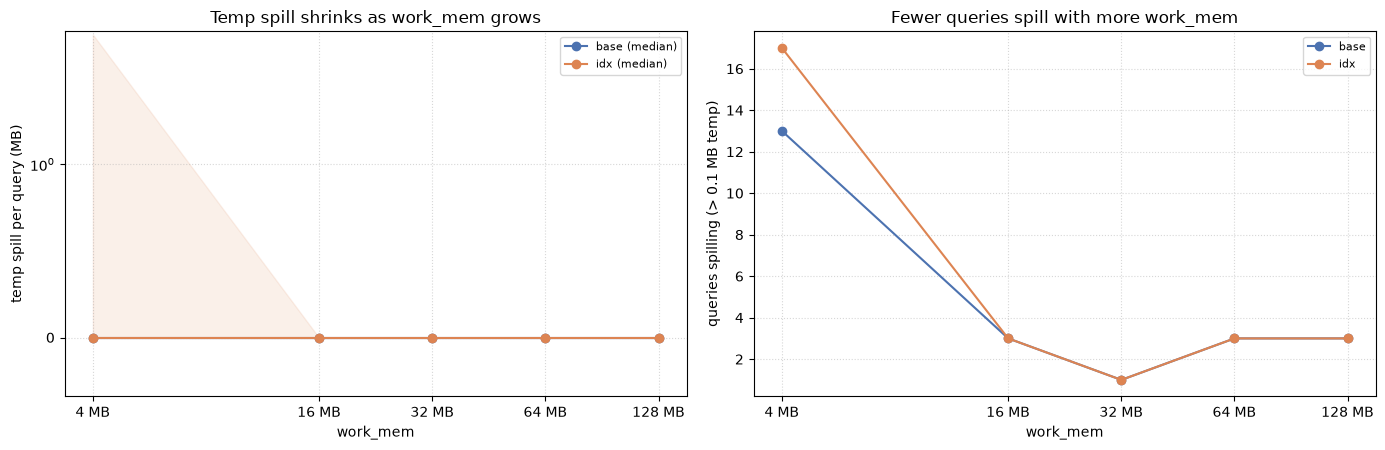

Queries whose temp spill falls most from 4 MB -> 128 MB work_mem (base):
                         temp_MB @4 MB  temp_MB @128 MB  speedup  temp_drop_MB
qid                                                                           
q17/v2_decorrelate.sql          714.28              0.0     0.46        714.28
q02/v1_materialized.sql          52.48              0.0     1.00         52.48
q02/base.sql                     52.48              0.0     0.98         52.48
q10/v1_materialized.sql          49.70              0.0     1.26         49.70
q10/base.sql                     42.82              0.0     1.21         42.82
q09/v1_materialized.sql          40.68              0.0     1.00         40.68
q09/base.sql                     40.68              0.0     1.01         40.68
q13/v1_materialized.sql          24.86              0.0     0.40         24.86
q13/base.sql                     24.81              0.0     0.40         24.81
q02/v2_decorrelate.sql            7.27              0.0   

In [4]:
SPILL_MB = 0.1   # a query "spills" at a value if it writes/reads > this much temp

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# (1) median temp spill vs work_mem
for ix in IDX_ALL:
    sub = data[data["index_status"] == ix]
    grp = sub.groupby("pval")["temp_mb"]
    med = grp.median()
    axes[0].plot(med.index, med.values, marker="o", color=colours[ix], label=f"{ix} (median)")
    q3 = grp.quantile(0.75)
    axes[0].fill_between(med.index, med.values, q3.values, color=colours[ix], alpha=0.12)
set_xaxis(axes[0])
axes[0].set_ylabel("temp spill per query (MB)")
axes[0].set_yscale("symlog", linthresh=1.0)
axes[0].set_title("Temp spill shrinks as work_mem grows")
axes[0].grid(linestyle=":", alpha=0.5); axes[0].legend(fontsize=8)

# (2) how many queries still spill at each work_mem
for ix in IDX_ALL:
    sub = data[data["index_status"] == ix]
    n_spill = sub[sub["temp_mb"] > SPILL_MB].groupby("pval")["qid"].nunique().reindex(PVALS, fill_value=0)
    axes[1].plot(PVALS, n_spill.values, marker="o", color=colours[ix], label=ix)
set_xaxis(axes[1])
axes[1].set_ylabel(f"queries spilling (> {SPILL_MB:g} MB temp)")
axes[1].set_title("Fewer queries spill with more work_mem")
axes[1].grid(linestyle=":", alpha=0.5); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

# queries whose spill (and runtime) falls most from smallest -> largest work_mem
base = data[data["index_status"] == "base"]
tp = base.pivot_table(index="qid", columns="pval", values="temp_mb").reindex(columns=PVALS)
rt = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
spill = pd.DataFrame({
    f"temp_MB @{p_label(PVALS[0])}": tp[PVALS[0]],
    f"temp_MB @{p_label(PVALS[-1])}": tp[PVALS[-1]],
    "speedup": rt[PVALS[0]] / rt[PVALS[-1]],
}).dropna()
spill["temp_drop_MB"] = spill.iloc[:, 0] - spill.iloc[:, 1]
spill = spill.sort_values("temp_drop_MB", ascending=False)
print(f"Queries whose temp spill falls most from {p_label(PVALS[0])} -> "
      f"{p_label(PVALS[-1])} work_mem (base):")
print(spill.head(10).round(2).to_string())
n0 = int((tp[PVALS[0]] > SPILL_MB).sum()); n1 = int((tp[PVALS[-1]] > SPILL_MB).sum())
print(f"\nQueries spilling: {n0} at {p_label(PVALS[0])} -> {n1} at {p_label(PVALS[-1])}.")

## 5. Runtime & energy vs work_mem — where does tuning pay off?

For each query, runtime and package energy are taken relative to their value at
the **smallest** work_mem setting, so `1.0` = same as the smallest and `< 1` =
faster / leaner. The heavy line is the median over queries; the summed totals per
setting say which value is best **overall**.

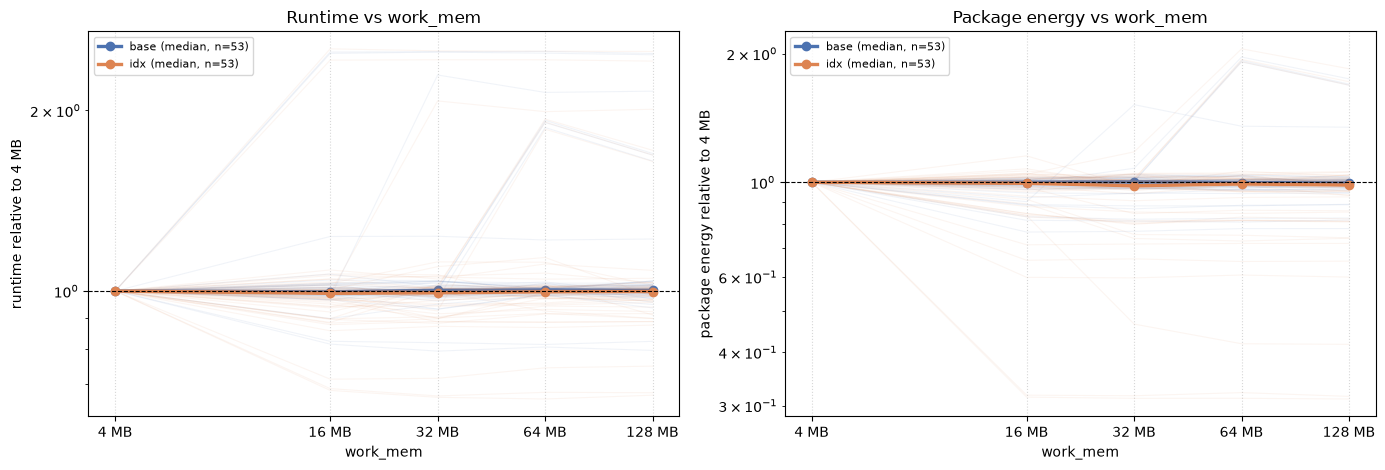

Total runtime / energy across the common query set, by work_mem:
index_status  pval  total_runtime_s  total_energy_j  queries
        base     4            137.5          1593.5       53
        base    16            140.8          1560.7       53
        base    32            142.6          1593.3       53
        base    64            149.9          1752.7       53
        base   128            148.3          1710.1       53
         idx     4             29.2           578.6       53
         idx    16             30.2           542.3       53
         idx    32             32.2           533.7       53
         idx    64             39.2           683.5       53
         idx   128             37.5           646.1       53
  [base] fastest total: 4 MB  |  lowest energy: 16 MB
  [idx] fastest total: 4 MB  |  lowest energy: 32 MB


In [5]:
def relative(metric, ix):
    # use only the values this variant covers broadly, so an incomplete point
    # (e.g. one query at the largest setting) doesn't collapse the whole line
    sub = data[data["index_status"] == ix]
    cov = sub.groupby("pval")["qid"].nunique()
    good = [m for m in PVALS if cov.get(m, 0) >= 0.5 * cov.max()]
    piv = sub.pivot_table(index="qid", columns="pval", values=metric).reindex(columns=good)
    piv = piv.dropna(how="any")
    rel = piv.div(piv[good[0]], axis=0) if not piv.empty else piv
    return good, piv, rel


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, metric, nice in ((axes[0], "avg_time_s", "runtime"),
                         (axes[1], "avg_pkg_j", "package energy")):
    for ix in IDX_ALL:
        good, piv, rel = relative(metric, ix)
        if rel.empty:
            continue
        for _, row in rel.iterrows():
            ax.plot(good, row.values, color=colours[ix], alpha=0.08, lw=0.8)
        ax.plot(good, rel.median().values, color=colours[ix], marker="o",
                lw=2.4, label=f"{ix} (median, n={len(rel)})")
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.set_yscale("log")
    set_xaxis(ax)
    ax.set_ylabel(f"{nice} relative to {p_label(PVALS[0])}")
    ax.set_title(f"{nice.capitalize()} vs work_mem"); ax.grid(linestyle=":", alpha=0.5)
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

tot = data.groupby(["index_status", "pval"]).agg(
    total_runtime_s=("avg_time_s", "sum"),
    total_energy_j=("avg_pkg_j", "sum"),
    queries=("qid", "nunique")).reset_index()
print("Total runtime / energy across the common query set, by work_mem:")
print(tot.round(1).to_string(index=False))
for ix in IDX_ALL:
    t = tot[tot["index_status"] == ix].set_index("pval")
    bt = t["total_runtime_s"].idxmin(); be = t["total_energy_j"].idxmin()
    print(f"  [{ix}] fastest total: {p_label(bt)}  |  lowest energy: {p_label(be)}")

## 6. Best work_mem per query — by runtime

Not every query benefits from the largest setting. For each query (base) we pick
the work_mem value with the lowest **runtime** (needing a margin over the
runner-up to count, else it is a **tie / flat**) and tally how many queries prefer
each value.

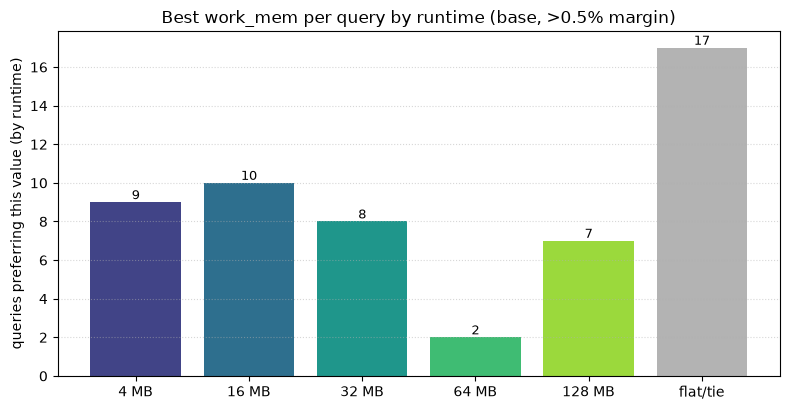

17/53 queries are flat on runtime (no value wins by >0.5%).

Queries that gain most runtime from the largest work_mem (base, speedup 4 MB -> 128 MB):
qid
q10/v1_materialized.sql    1.26
q10/base.sql               1.21
q11/v1_materialized.sql    1.07
q11/base.sql               1.05
q06/base.sql               1.04
q22/v2_anti_join.sql       1.03
q14/base.sql               1.03
q13/v2_correlated.sql      1.02
q05/base.sql               1.02
q03/base.sql               1.02


In [6]:
MARGIN_PCT = 0.5     # must beat the next value by >this % to "prefer" it

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
m = m.dropna(how="any")
thr = 1 + MARGIN_PCT / 100.0
arr = m.to_numpy()
order = np.argsort(arr, axis=1)
rows = np.arange(len(arr))
best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
winner = np.where(runner > best * thr,
                  np.array(PVALS)[order[:, 0]].astype(object), "flat/tie")
pref = pd.Series(winner, index=m.index)
counts = pref.value_counts()

labels = [p_label(v) for v in PVALS] + ["flat/tie"]
vals = [int(counts.get(v, 0)) for v in PVALS] + [int(counts.get("flat/tie", 0))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(labels)), vals,
       color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(PVALS)))) + [(0.7, 0.7, 0.7, 1)])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel("queries preferring this value (by runtime)")
ax.set_title(f"Best work_mem per query by runtime (base, >{MARGIN_PCT:g}% margin)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"{int((pref == 'flat/tie').sum())}/{len(pref)} queries are flat on runtime "
      f"(no value wins by >{MARGIN_PCT:g}%).")
print("\nQueries that gain most runtime from the largest work_mem (base, "
      f"speedup {p_label(PVALS[0])} -> {p_label(PVALS[-1])}):")
gain = (m[PVALS[0]] / m[PVALS[-1]]).sort_values(ascending=False)
print(gain.head(10).round(2).to_string())

## 6b. Full ranking by runtime — how every value places across queries

Section 6 counted only each query's *winner*. This ranks **all** work_mem values
per query into 1st / 2nd / 3rd / … place (base **runtimes**) with the same
`MARGIN_PCT`: values within that margin of a place's best **share** that place.
Every bar therefore totals the query count, coloured by the place that value took
— a mostly-green value is the safe default; lots of red means it is usually the
worst choice.

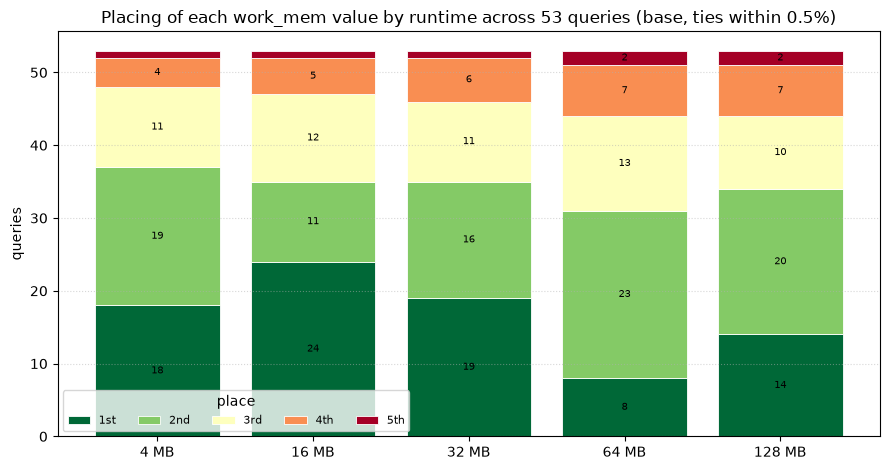

runtime placings across 53 queries (ties within 0.5% share a place):
        1st  2nd  3rd  4th  5th
4 MB     18   19   11    4    1
16 MB    24   11   12    5    1
32 MB    19   16   11    6    1
64 MB     8   23   13    7    2
128 MB   14   20   10    7    2


In [7]:
MARGIN_PCT = 0.5     # values within this % of a place's best share that place

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
m = m.dropna(how="any")


def positions(row):
    place, gbest = 0, None
    out = {}
    for k in sorted(PVALS, key=lambda kk: row[kk]):
        if gbest is None or row[k] > gbest * (1 + MARGIN_PCT / 100.0):
            place += 1
            gbest = row[k]
        out[k] = place
    return pd.Series(out)


posdf = m.apply(positions, axis=1)          # qid x pval -> place (1..)
maxpos = int(posdf.to_numpy().max())
counts = {v: posdf[v].value_counts() for v in PVALS}


def ordinal(k):
    return {1: "1st", 2: "2nd", 3: "3rd"}.get(k, f"{k}th")


def place_colour(p):
    frac = 1.0 if maxpos == 1 else (maxpos - p) / (maxpos - 1)
    return plt.cm.RdYlGn(frac)


fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(PVALS))
bottom = np.zeros(len(PVALS))
for p in range(1, maxpos + 1):
    vals = np.array([int(counts[v].get(p, 0)) for v in PVALS], dtype=float)
    ax.bar(x, vals, bottom=bottom, color=place_colour(p), label=ordinal(p),
           edgecolor="white", linewidth=0.6)
    for xi, (vv, b) in enumerate(zip(vals, bottom)):
        if vv >= 2:
            ax.text(xi, b + vv / 2, int(vv), ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels([p_label(v) for v in PVALS])
ax.set_ylabel("queries")
ax.set_title(f"Placing of each work_mem value by runtime across {len(m)} queries "
             f"(base, ties within {MARGIN_PCT:g}%)")
ax.legend(title="place", fontsize=8, ncol=maxpos)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

summary = pd.DataFrame(
    {ordinal(p): [int(counts[v].get(p, 0)) for v in PVALS]
     for p in range(1, maxpos + 1)},
    index=[p_label(v) for v in PVALS])
print(f"runtime placings across {len(m)} queries (ties within {MARGIN_PCT:g}% share a place):")
print(summary.to_string())

## 6c. Best work_mem per query — by energy

The same tally as §6, but ranking each query's values by **package energy**
(`avg_pkg_j`) instead of runtime. Because energy = power × time and power is not
constant across settings (e.g. more parallel workers draw more watts), the
lowest-energy value can differ from the fastest one — this is where that shows up.

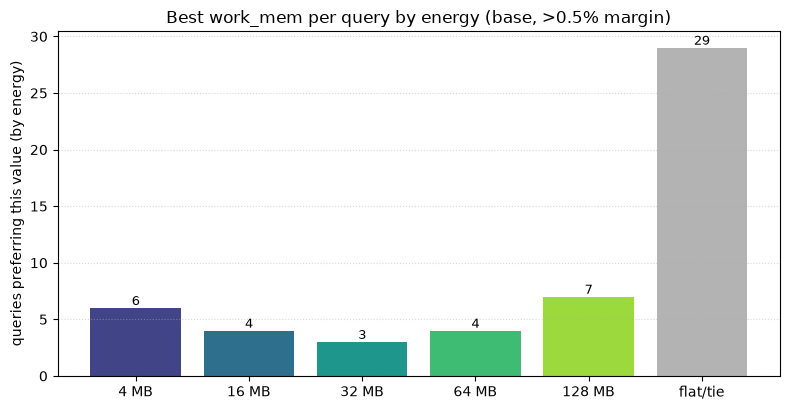

29/53 queries are flat on energy (no value wins by >0.5%).

Queries that gain most energy from the largest work_mem (base, energy ratio 4 MB -> 128 MB):
qid
q01/base.sql               1.28
q13/v1_materialized.sql    1.23
q13/base.sql               1.21
q10/v1_materialized.sql    1.13
q10/base.sql               1.13
q22/v1_materialized.sql    1.06
q02/v2_decorrelate.sql     1.06
q09/v1_materialized.sql    1.04
q09/base.sql               1.04
q16/v2_not_exists.sql      1.03


In [8]:
MARGIN_PCT = 0.5     # must beat the next value by >this % to "prefer" it

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_pkg_j").reindex(columns=PVALS)
m = m.dropna(how="any")
thr = 1 + MARGIN_PCT / 100.0
arr = m.to_numpy()
order = np.argsort(arr, axis=1)
rows = np.arange(len(arr))
best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
winner = np.where(runner > best * thr,
                  np.array(PVALS)[order[:, 0]].astype(object), "flat/tie")
pref = pd.Series(winner, index=m.index)
counts = pref.value_counts()

labels = [p_label(v) for v in PVALS] + ["flat/tie"]
vals = [int(counts.get(v, 0)) for v in PVALS] + [int(counts.get("flat/tie", 0))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(labels)), vals,
       color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(PVALS)))) + [(0.7, 0.7, 0.7, 1)])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel("queries preferring this value (by energy)")
ax.set_title(f"Best work_mem per query by energy (base, >{MARGIN_PCT:g}% margin)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"{int((pref == 'flat/tie').sum())}/{len(pref)} queries are flat on energy "
      f"(no value wins by >{MARGIN_PCT:g}%).")
print("\nQueries that gain most energy from the largest work_mem (base, "
      f"energy ratio {p_label(PVALS[0])} -> {p_label(PVALS[-1])}):")
gain = (m[PVALS[0]] / m[PVALS[-1]]).sort_values(ascending=False)
print(gain.head(10).round(2).to_string())

## 6d. Full ranking by energy — how every value places across queries

The §6b placings, but ranking all work_mem values per query by **package energy**
rather than runtime. Compare the colours against §6b: a value that is usually
fastest but not usually lowest-energy (or vice-versa) reveals a time-vs-energy
trade-off in this parameter.

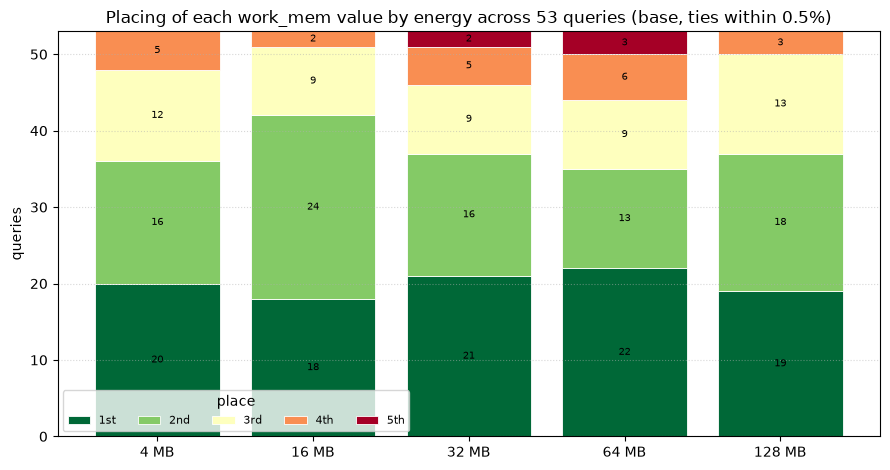

energy placings across 53 queries (ties within 0.5% share a place):
        1st  2nd  3rd  4th  5th
4 MB     20   16   12    5    0
16 MB    18   24    9    2    0
32 MB    21   16    9    5    2
64 MB    22   13    9    6    3
128 MB   19   18   13    3    0


In [9]:
MARGIN_PCT = 0.5     # values within this % of a place's best share that place

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_pkg_j").reindex(columns=PVALS)
m = m.dropna(how="any")


def positions(row):
    place, gbest = 0, None
    out = {}
    for k in sorted(PVALS, key=lambda kk: row[kk]):
        if gbest is None or row[k] > gbest * (1 + MARGIN_PCT / 100.0):
            place += 1
            gbest = row[k]
        out[k] = place
    return pd.Series(out)


posdf = m.apply(positions, axis=1)          # qid x pval -> place (1..)
maxpos = int(posdf.to_numpy().max())
counts = {v: posdf[v].value_counts() for v in PVALS}


def ordinal(k):
    return {1: "1st", 2: "2nd", 3: "3rd"}.get(k, f"{k}th")


def place_colour(p):
    frac = 1.0 if maxpos == 1 else (maxpos - p) / (maxpos - 1)
    return plt.cm.RdYlGn(frac)


fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(PVALS))
bottom = np.zeros(len(PVALS))
for p in range(1, maxpos + 1):
    vals = np.array([int(counts[v].get(p, 0)) for v in PVALS], dtype=float)
    ax.bar(x, vals, bottom=bottom, color=place_colour(p), label=ordinal(p),
           edgecolor="white", linewidth=0.6)
    for xi, (vv, b) in enumerate(zip(vals, bottom)):
        if vv >= 2:
            ax.text(xi, b + vv / 2, int(vv), ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels([p_label(v) for v in PVALS])
ax.set_ylabel("queries")
ax.set_title(f"Placing of each work_mem value by energy across {len(m)} queries "
             f"(base, ties within {MARGIN_PCT:g}%)")
ax.legend(title="place", fontsize=8, ncol=maxpos)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

summary = pd.DataFrame(
    {ordinal(p): [int(counts[v].get(p, 0)) for v in PVALS]
     for p in range(1, maxpos + 1)},
    index=[p_label(v) for v in PVALS])
print(f"energy placings across {len(m)} queries (ties within {MARGIN_PCT:g}% share a place):")
print(summary.to_string())

## 7. Indexing vs work_mem — which lever matters more?

Two ways to make a query faster: tune work_mem, or add an index. This compares,
per query, the **work_mem speedup** (base runtime at the smallest vs largest
setting) against the **indexing speedup** (base vs indexed at a fixed, common
setting). Points above the diagonal are helped more by an index; points to the
right are helped more by tuning work_mem.

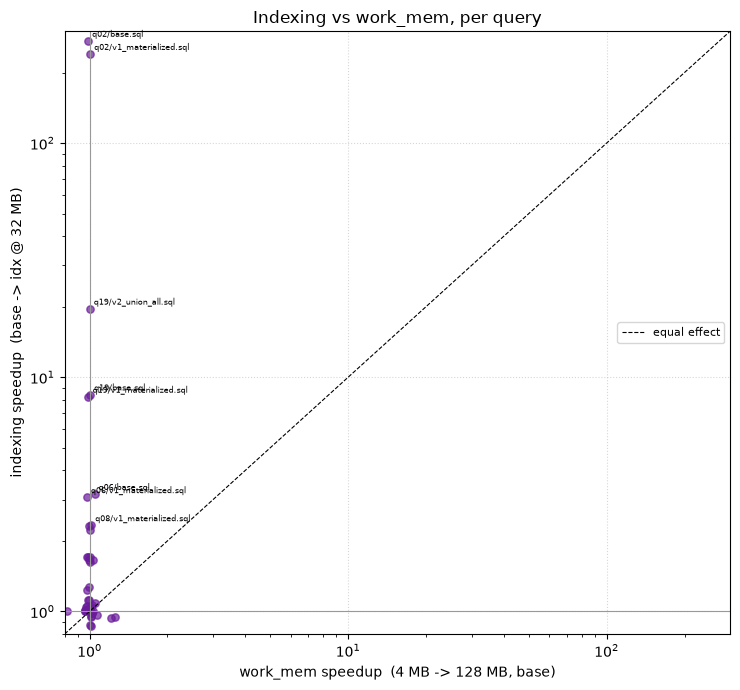

At 32 MB: indexing beats work_mem tuning for 39/53 queries; work_mem wins for 14.


In [10]:
common_pv = [m for m in PVALS
             if {"base", "idx"} <= set(data.loc[data["pval"] == m, "index_status"])]
if not common_pv:
    print("No work_mem value has both base and indexed runs - "
          "cannot compare indexing vs work_mem yet.")
else:
    fix = common_pv[len(common_pv) // 2]           # a middle common value
    base = data[data["index_status"] == "base"]
    rt = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
    tuning = (rt[PVALS[0]] / rt[PVALS[-1]]).rename("tuning_x")

    bt = data[(data["index_status"] == "base") & (data["pval"] == fix)].set_index("qid")["avg_time_s"]
    it = data[(data["index_status"] == "idx") & (data["pval"] == fix)].set_index("qid")["avg_time_s"]
    indexing = (bt / it).rename("indexing_x")

    comp = pd.concat([tuning, indexing], axis=1).dropna()
    comp = comp[(comp["tuning_x"] > 0) & (comp["indexing_x"] > 0)]
    fig, ax = plt.subplots(figsize=(7.5, 7))
    ax.scatter(comp["tuning_x"], comp["indexing_x"], s=28, alpha=0.7, color="#6a1b9a")
    lim = [0.8, max(3.0, comp.to_numpy().max() * 1.1)]
    ax.plot(lim, lim, color="k", lw=0.8, ls="--", label="equal effect")
    ax.axhline(1, color="0.6", lw=0.8); ax.axvline(1, color="0.6", lw=0.8)
    for q, row in comp.sort_values(["indexing_x", "tuning_x"]).tail(8).iterrows():
        ax.annotate(q, (row["tuning_x"], row["indexing_x"]), fontsize=6,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"work_mem speedup  ({p_label(PVALS[0])} -> {p_label(PVALS[-1])}, base)")
    ax.set_ylabel(f"indexing speedup  (base -> idx @ {p_label(fix)})")
    ax.set_title("Indexing vs work_mem, per query")
    ax.legend(fontsize=8); ax.grid(linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

    idx_wins = int((comp["indexing_x"] > comp["tuning_x"]).sum())
    print(f"At {p_label(fix)}: indexing beats work_mem tuning for {idx_wins}/{len(comp)} "
          f"queries; work_mem wins for {len(comp) - idx_wins}.")